# Analysis of Policy Claims in Academic Abstracts

This notebook analyzes the classified abstracts to explore trends in policy claims over time and across different academic journals.

# 1. Setup and Configuration

First, we import the necessary libraries and set up the key configuration variables for our analysis. **Please edit these variables to match your file paths and column names.**

We also load the dataset and prepare it for analysis e.g., creating a numeric version of our policy claim variable

## Install packages

In [40]:
# --- ENVIRONMENT CHECK ---
import sys
import subprocess

print(f"Python version: {sys.version.split()[0]}")

# --- REQUIRED PACKAGES ---
required = [
    "pandas", "numpy", "matplotlib", "seaborn", "ydata_profiling",
    "statsmodels", "nltk", "python-docx"
]

for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", pkg],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
        except subprocess.CalledProcessError:
            print(f"Warning: could not install '{pkg}'. Install it manually.")

# --- MATPLOTLIB BACKEND ---
%matplotlib inline
import matplotlib as mpl
print(f"Matplotlib backend: {mpl.get_backend()}")


Python version: 3.13.6
Matplotlib backend: inline


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- SINGLE DATA LOAD: run this cell once before the analysis cells ---
ROOT = Path("..")
ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
CLAIM_COLUMN = "llm_policy_claim"
JOURNAL_COLUMN = "journal"
YEAR_COLUMN = "publication_year"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def rel_path(path: Path) -> str:
    return path.as_posix()


def load_analysis_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        data = pd.read_csv(path)
    elif path.suffix.lower() == ".json":
        data = pd.read_json(path)
    else:
        raise ValueError(f"Input file must be .csv or .json, got: {rel_path(path)}")

    required = [CLAIM_COLUMN, JOURNAL_COLUMN, YEAR_COLUMN]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise KeyError(f"Missing required columns in {rel_path(path)}: {missing}")

    print(f"Loaded {len(data):,} records from {rel_path(path)}")

    data = data.dropna(subset=[CLAIM_COLUMN]).copy()
    data[YEAR_COLUMN] = pd.to_numeric(data[YEAR_COLUMN], errors="coerce")
    data[JOURNAL_COLUMN] = data[JOURNAL_COLUMN].astype(str).str.title()
    data[CLAIM_COLUMN] = data[CLAIM_COLUMN].astype(bool)
    data["claim"] = data[CLAIM_COLUMN].astype(int)

    print(f"Analytic rows after dropping missing {CLAIM_COLUMN}: {len(data):,}")
    print("Claim counts:\n" + data[CLAIM_COLUMN].value_counts(dropna=False).to_string())
    if "design_combined" in data.columns:
        n_design = int(data["design_combined"].ne("Other/None").sum())
        print(f"Rows with design_combined != Other/None: {n_design:,}")

    return data.reset_index(drop=True)


analysis_df = load_analysis_dataset(ANALYSIS_DATA_FILE)
df = analysis_df.copy()
df.head()


## Create derived variables

In [ ]:
import pandas as pd
from pathlib import Path
import re

# Output; input is the centrally loaded df from the first setup cell.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before exporting the minimal dataset.")

df = analysis_df.copy()
print(f"Export source: {rel_path(ANALYSIS_DATA_FILE)}")

EXPORT_DIR = Path("../derived_data")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_FILE = EXPORT_DIR / "policy_claims_minimal.csv"

# Expected columns (exact names, as provided)
EXPECTED_COLS = [
    "scopus_id",
    "doi",
    "title",
    "journal",
    "publication_year",
    "keywords",
    "abstract",
    "article_type",
    "corresponding_author_country",
    "cited_by_count",
    "llm_policy_claim",
]

# Quick sanity check
missing = [c for c in EXPECTED_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

# Select the fields we will publish (no abstracts or other proprietary text)
out = df[[
    "doi",
    "title",
    "journal",
    "publication_year",
    "keywords",  # ensure these are your own derived/public keywords before publishing
    "corresponding_author_country",
    "llm_policy_claim",
]].copy()

# --- Minimal cleaning --- #

# DOI: normalize (lowercase, strip doi.org prefix)
out["doi"] = (
    out["doi"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True)
)

# Title/Journal trim whitespace; title left as-is (no case mangling)
for col in ["title", "journal", "corresponding_author_country"]:
    out[col] = out[col].astype(str).str.strip()

# Year: numeric (nullable int)
out["publication_year"] = pd.to_numeric(out["publication_year"], errors="coerce").astype("Int64")

# Claim: cast to binary int (0/1)
out["llm_policy_claim"] = out["llm_policy_claim"].astype(bool)

# Keywords: if list-like, join; otherwise keep string (strip)
def _norm_keywords(x):
    if isinstance(x, (list, tuple, set)):
        return "; ".join(map(str, x))
    s = None if pd.isna(x) else str(x).strip()
    return s if s else None

out["keywords"] = out["keywords"].apply(_norm_keywords)

# Drop rows missing essential fields, and deduplicate by DOI
before = len(out)
out = out.dropna(subset=["doi", "title"]).query("doi != ''").drop_duplicates(subset=["doi"]).reset_index(drop=True)
after = len(out)

print(f"Export rows: {after} (dropped {before - after} empty/duplicate DOI rows).")
print("llm_policy_claim counts:\n", out["llm_policy_claim"].value_counts(dropna=False))
if out["publication_year"].notna().any():
    print("Year range:", int(out["publication_year"].min()), "→", int(out["publication_year"].max()))

# Write
out.to_csv(EXPORT_FILE, index=False)
print(f"Wrote: {rel_path(EXPORT_FILE)}")


## Sense checks: cross-tabs by year and journal

In [43]:
#simple cross-tabs, by year and journal.... 
# Percent policy claim by year
year_pct = df.groupby('publication_year')['llm_policy_claim'].mean() * 100
print(year_pct)

# Percent policy claim by journal
journal_pct = df.groupby('journal')['llm_policy_claim'].mean() * 100
print(journal_pct)

publication_year
1990    12.529002
1991    16.831683
1992    13.807531
1993    19.194062
1994    18.492462
1995    17.913386
1996    18.333333
1997    17.709180
1998    19.915612
1999    19.777601
2000    19.781079
2001    20.093095
2002    19.519833
2003    21.190893
2004    23.592085
2005    23.298639
2006    23.184818
2007    23.732550
2008    23.606811
2009    28.332170
2010    27.233429
2011    24.826147
2012    26.134056
2013    28.156491
2014    25.160163
2015    28.199189
2016    27.449514
2017    32.168285
2018    32.318210
2019    32.163743
2020    34.909910
2021    36.384705
2022    36.730889
2023    34.557235
2024    36.232980
Name: llm_policy_claim, dtype: float64
journal
American Journal Of Epidemiology                 9.892744
American Journal Of Preventive Medicine         38.145721
American Journal Of Public Health               33.674907
Epidemiology                                     3.683536
European Journal Of Epidemiology                14.397906
European Journal

In [44]:
# Tabulate % True, False, and missing for a column - note n=1 is missing
col = 'llm_policy_claim'
tab = df[col].value_counts(dropna=False, normalize=False) 
print(tab)

llm_policy_claim
False    34072
True     11735
Name: count, dtype: int64


# Confirm sample size / analytical N

In [38]:
# 1) Overall analytic N you expect vs. what Table 1 sees
print("Total rows:", len(df))
print("Rows with non-missing publication_year:", df['publication_year'].notna().sum())

# 2) Non-numeric or malformed years
tmp = pd.to_numeric(df['publication_year'], errors='coerce')
print("Non-numeric/malformed years:", (tmp.isna() & df['publication_year'].notna()).sum())

# 3) Years outside your window
print("Years outside 1990–2024:", ((tmp < 1990) | (tmp > 2024)).sum())

# 4) Rows with missing abstracts
print("Rows with missing abstracts:", df['abstract'].isna().sum())

Total rows: 45807
Rows with non-missing publication_year: 45807
Non-numeric/malformed years: 0
Years outside 1990–2024: 0
Rows with missing abstracts: 0


In [ ]:
import importlib.util
from pathlib import Path
import pandas as pd
import re

script = Path("./2_filter_records.py")
assert script.exists(), f"Not found: {script.as_posix()}"
spec = importlib.util.spec_from_file_location("filter_records", script)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

in_dir = Path("../data/json_files")
files = sorted(in_dir.glob("*.json"))
if not files:
    # Fall back to the combined filtered file when raw journal files are absent
    fallback = in_dir / "filtered" / "all_abstracts.json"
    assert fallback.exists(), f"No raw JSON files in {in_dir} and no fallback at {fallback}"
    print(f"No raw JSON files found; loading combined file: {fallback}")
    files = [fallback]

records = []
for p in files:
    records.extend(mod.load_json(p))

df_raw = pd.DataFrame.from_records(records)
print("Raw records:", len(df_raw))

kept, dropped, counts = mod.filter_df(df_raw)
print("Kept after content filters:", len(kept))          # expect 45808
print("Dropped:", len(dropped))                           # expect 4725
print("Exclusion reasons:", dict(counts))

# Optional year window 1990-2024 
YEAR = "publication_year"
kept[YEAR] = pd.to_numeric(kept[YEAR], errors="coerce")
kept = kept[(kept[YEAR] >= 1990) & (kept[YEAR] <= 2024)].copy()
print("Kept after year window:", len(kept))

labels_path = Path("../data/json_files/filtered/all_abstracts_LLM.csv")
lab = pd.read_csv(labels_path, usecols=["scopus_id", "doi", "llm_policy_claim"])

# Prepare deduped lookups
lab_scopus = lab.dropna(subset=["scopus_id"]).drop_duplicates(subset=["scopus_id"])
lab_doi    = lab.dropna(subset=["doi"]).drop_duplicates(subset=["doi"])

# Merge on scopus_id first
kept_labeled = kept.merge(
    lab_scopus[["scopus_id", "llm_policy_claim"]],
    how="left",
    on="scopus_id"
)

# Fill remaining missing labels using DOI
mask_unlabeled = kept_labeled["llm_policy_claim"].isna()
if mask_unlabeled.any():
    kept_labeled = kept_labeled.merge(
        lab_doi[["doi", "llm_policy_claim"]].rename(columns={"llm_policy_claim": "llm_policy_claim_doi"}),
        how="left",
        on="doi"
    )
    kept_labeled.loc[mask_unlabeled, "llm_policy_claim"] = kept_labeled.loc[mask_unlabeled, "llm_policy_claim_doi"]
    kept_labeled.drop(columns=["llm_policy_claim_doi"], inplace=True, errors="ignore")

print("Missing LLM label after merge:", kept_labeled["llm_policy_claim"].isna().sum())

# Validation cross-check (does not replace df loaded from enriched CSV)
df_validation = kept_labeled[kept_labeled["llm_policy_claim"].notna()].copy().reset_index(drop=True)
print("Analytical N (after dropping unlabeled):", len(df_validation))  # expect 45807

print("Rows with non-missing publication_year:", df_validation['publication_year'].notna().sum())
tmp_year = pd.to_numeric(df_validation['publication_year'], errors='coerce')
print("Years outside 1990–2024:", ((tmp_year < 1990) | (tmp_year > 2024)).sum())
print("Rows with missing abstracts:", df_validation['abstract'].isna().sum())


In [20]:
def mk_key(x):
    doi = x.get("doi", pd.Series("", index=x.index)).astype(str).str.lower().str.strip() \
           .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True)
    yr  = pd.to_numeric(x.get("publication_year", np.nan), errors="coerce").fillna(-1).astype(int).astype(str)
    ttl = x.get("title",  pd.Series("", index=x.index)).astype(str).str.lower().str.strip()
    jnl = x.get("journal",pd.Series("", index=x.index)).astype(str).str.lower().str.strip()
    return doi.where(doi.ne("") & doi.ne("nan"), ttl + "|" + jnl + "|" + yr)

k = kept.assign(__key=mk_key(kept))
d = df.assign(__key=mk_key(df))

miss = (
    k.merge(d[["__key"]].drop_duplicates(), on="__key", how="left", indicator=True)
     .query("_merge == 'left_only'")
)

cols = [c for c in ["scopus_id","doi","title","journal","publication_year"] if c in miss.columns]
print(miss[cols].to_string(index=False))

           scopus_id                                doi                                                                                                                                   title                          journal  publication_year
SCOPUS_ID:0031474246 10.1093/oxfordjournals.aje.a009240 High rates of HIV infection among injection drug users participating in needle exchange programs in Montreal: Results of a cohort study American Journal of Epidemiology              1997


In [21]:
doi = "10.1093/oxfordjournals.aje.a009240"

def norm_doi(s):
    return (s.astype(str).str.strip().str.lower()
            .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True))

llm = pd.read_csv("../data/json_files/filtered/all_abstracts_LLM.csv")
llm["doi_norm"] = norm_doi(llm.get("doi", pd.Series(index=llm.index)))

row = llm.loc[llm["doi_norm"].eq(doi), ["doi","journal","publication_year","llm_policy_claim"]]
print(row if not row.empty else "DOI not present in LLM file")

# Confirm it is missing from df after you dropped NaNs in llm_policy_claim
d = df.assign(doi_norm=norm_doi(df.get("doi", pd.Series(index=df.index))))
print("In df:", d["doi_norm"].eq(doi).any())

                                     doi                           journal  \
1720  10.1093/oxfordjournals.aje.a009240  American Journal of Epidemiology   

      publication_year llm_policy_claim  
1720              1997              NaN  
In df: False


In [22]:
# sense check: Check unique journal names and count - in case of spelling inconsistencies. should be n=10 journals
print('JOURNAL_COLUMN variable:', JOURNAL_COLUMN)
print('Unique journal names in DataFrame:')
print(df[JOURNAL_COLUMN].unique())
print('Number of unique journals:', df[JOURNAL_COLUMN].nunique())

# New: Inspect and standardize corresponding_author_country
print('\n--- Corresponding author country check ---')
if 'corresponding_author_country' in df.columns:
    # Raw counts as DataFrame with column named 'N'
    raw_counts = df['corresponding_author_country'].value_counts(dropna=False)
    raw_counts_df = raw_counts.reset_index().rename(columns={'index': 'country', 'corresponding_author_country': 'N'})
    print('Value counts (raw):')
    print(raw_counts_df.head(50).to_string(index=False))

    # Standardize: strip whitespace, convert to upper case, treat empty strings and nulls as UNKNOWN
    df['corresponding_author_country'] = (
        df['corresponding_author_country']
        .astype(str)
        .str.strip()
        .replace({'nan': None})
    )
    df['corresponding_author_country'] = (
        df['corresponding_author_country']
        .fillna('UNKNOWN')
        .replace({'': 'UNKNOWN'})
        .str.upper()
    )

    # Standardized counts as DataFrame with column 'N'
    std_counts = df['corresponding_author_country'].value_counts()
    std_counts_df = std_counts.reset_index().rename(columns={'index': 'country', 'corresponding_author_country': 'N'})
    print('\nAfter standardization:')
    print(std_counts_df.head(50).to_string(index=False))

    # Number of unique countries
    print('\nNumber of unique countries (N):', df['corresponding_author_country'].nunique())
else:
    print('Column "corresponding_author_country" not found in dataframe')

JOURNAL_COLUMN variable: journal
Unique journal names in DataFrame:
['American Journal Of Epidemiology'
 'American Journal Of Preventive Medicine'
 'American Journal Of Public Health' 'Epidemiology'
 'European Journal Of Epidemiology' 'European Journal Of Public Health'
 'International Journal Of Epidemiology'
 'Journal Of Epidemiology And Community Health' 'The Lancet Public Health'
 'Preventive Medicine']
Number of unique journals: 10

--- Corresponding author country check ---
Value counts (raw):
                 N  count
     UNITED STATES  23417
    UNITED KINGDOM   4033
            CANADA   1665
       NETHERLANDS   1608
         AUSTRALIA   1370
            SWEDEN   1201
            FRANCE   1108
             SPAIN    998
           DENMARK    965
           FINLAND    936
             ITALY    895
           GERMANY    740
             CHINA    718
             JAPAN    613
            NORWAY    610
           UNKNOWN    356
       SWITZERLAND    348
           BELGIUM    284
 

# Main analysis

## Table 1: Key Characteristics of the Dataset

This table provides a high-level summary of the entire dataset, including the total number of articles, the overall rate of policy claims, and the diversity of journals and countries represented.

In [ ]:
# Reuse the dataset loaded in the first setup cell. No file is read here.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before this section so analysis_df is available.")

df = analysis_df.copy()
print(f"Using centrally loaded data: {rel_path(ANALYSIS_DATA_FILE)}")
print(f"Rows available: {len(df):,}")
df.head()


*Table 1. Characteristics of Epidemiology/Public Health abstracts: policy claims by year, journal, and country*

In [24]:
import pandas as pd
import numpy as np

# Define time periods with accurate labels
periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

# Get top 10 journals by article count
top_10_journals = df['journal'].value_counts().head(10).index.tolist()

# Calculate policy claim rates for 2020-2024 to sort journals
period_2020_df = df[(df['publication_year'] >= 2020) & (df['publication_year'] < 2025)]
journal_policy_rates = {}

for journal in top_10_journals:
    journal_df = period_2020_df[period_2020_df['journal'] == journal]
    n_journal_articles = len(journal_df)
    
    if n_journal_articles > 0:
        journal_policy_claims = (journal_df['claim'] == 1).sum()
        pct_journal_policy = (journal_policy_claims / n_journal_articles * 100)
        journal_policy_rates[journal] = pct_journal_policy
    else:
        journal_policy_rates[journal] = 0

# Sort journals by policy claim rate (ascending, so lowest first, highest last)
sorted_journals = sorted(journal_policy_rates.keys(), key=lambda x: journal_policy_rates[x])

# Get top 15 countries by publication count
top_15_countries = df['corresponding_author_country'].value_counts().head(15).index.tolist()

# Calculate policy claim rates for 2020-2024 to sort countries
country_policy_rates = {}

for country in top_15_countries:
    country_df = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    n_country_articles = len(country_df)
    
    if n_country_articles > 0:
        country_policy_claims = (country_df['claim'] == 1).sum()
        pct_country_policy = (country_policy_claims / n_country_articles * 100)
        country_policy_rates[country] = pct_country_policy
    else:
        country_policy_rates[country] = 0

# Sort countries by policy claim rate (ascending, so lowest first, highest last)
sorted_countries = sorted(country_policy_rates.keys(), key=lambda x: country_policy_rates[x])

# Initialize results dictionary
results = {}
row_names = []
categories = []

# Metrics to calculate
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

# Initialize results structure for base metrics
for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

# Add "All journals/countries" row
results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

# Add journal heading
results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

# Initialize results structure for journal-specific metrics (in sorted order)
for i, journal in enumerate(sorted_journals):
    results[f'  {journal}'] = {}
    row_names.append(f'  {journal}')
    categories.append('Journal')

# Add country heading
results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

# Initialize results structure for country-specific metrics (in sorted order)
for i, country in enumerate(sorted_countries):
    # Format country name: capitalize first letter only
    country_formatted = country.capitalize() if isinstance(country, str) else country
    results[f'  {country_formatted}'] = {}
    row_names.append(f'  {country_formatted}')
    categories.append('Country')

# Calculate metrics for each period
for period_name, (start_year, end_year) in periods.items():
    # Filter data for the period
    period_df = df[(df['publication_year'] >= start_year) & (df['publication_year'] < end_year)]
    
    # Number of articles
    n_articles = len(period_df)
    results['Number of articles, N'][period_name] = n_articles
    
    # Number of unique journals
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()
    
    # Words in abstracts - calculate word count for each abstract
    word_counts = period_df['abstract'].fillna('').str.split().str.len()
    mean_words = word_counts.mean()
    sd_words = word_counts.std()
    results['Words in abstracts, mean (SD)'][period_name] = f"{mean_words:.1f} ({sd_words:.1f})" if not pd.isna(mean_words) else "N/A"
    
    # Papers with keywords included (not null, not empty list, not empty string)
    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True
    
    papers_with_keywords = period_df['keywords'].apply(has_keywords).sum()
    pct_with_keywords = (papers_with_keywords / n_articles * 100) if n_articles > 0 else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_with_keywords:.1f}"
    
    # Countries of corresponding author - count unique countries
    results['Countries of corresponding author, N'][period_name] = period_df['corresponding_author_country'].nunique()
    
    # Policy claims - count papers where claim == 1
    papers_with_policy = (period_df['claim'] == 1).sum()
    pct_policy = (papers_with_policy / n_articles * 100) if n_articles > 0 else 0
    results['Policy claims, N (%)'][period_name] = f"{papers_with_policy} ({pct_policy:.1f})"
    
    # All journals/countries % policy claims
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"
    
    # Journal heading (empty)
    results['Journals, policy claim rate (%)'][period_name] = ""
    
    # Calculate policy claim percentages for each of the top 10 journals (in sorted order)
    for journal in sorted_journals:
        journal_df = period_df[period_df['journal'] == journal]
        n_journal_articles = len(journal_df)
        
        if n_journal_articles > 0:
            journal_policy_claims = (journal_df['claim'] == 1).sum()
            pct_journal_policy = (journal_policy_claims / n_journal_articles * 100)
            results[f'  {journal}'][period_name] = f"{pct_journal_policy:.1f}"
        else:
            results[f'  {journal}'][period_name] = "N/A"
    
    # Country heading (empty)
    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    
    # Calculate policy claim percentages for each of the top 15 countries (in sorted order)
    for country in sorted_countries:
        country_df = period_df[period_df['corresponding_author_country'] == country]
        n_country_articles = len(country_df)
        
        # Format country name: capitalize first letter only
        country_formatted = country.capitalize() if isinstance(country, str) else country
        
        if n_country_articles > 0:
            country_policy_claims = (country_df['claim'] == 1).sum()
            pct_country_policy = (country_policy_claims / n_country_articles * 100)
            results[f'  {country_formatted}'][period_name] = f"{pct_country_policy:.1f}"
        else:
            results[f'  {country_formatted}'][period_name] = "N/A"

# Create the table with correct orientation (metrics as rows, periods as columns)
table1 = pd.DataFrame(results).T

# Rename the index to remove the default "name" label
table1.index.name = None

# Create a styled version for display in Jupyter
from IPython.display import HTML

# Create HTML table with bold for Journals and Countries rows
def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr>"
    
    # Header row
    html += "<th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"
    
    # Data rows
    for i, row_name in enumerate(row_names):
        if row_name in [
    'Journals, policy claim rate (%)',
    'Countries (first author), policy claim rate (%)'
]:
            html += f"<tr><td><b>{row_name}</b></td>"
        else:
            html += f"<tr><td>{row_name}</td>"
        
        for col in table_df.columns:
            html += f"<td>{table_df.loc[row_names[i], col]}</td>"
        html += "</tr>"
    
    html += "</table>"
    return html

# Display the table
print("\nTable 1: Descriptive Statistics by Time Period")
print("="*120)
print(table1.to_string())

# Also display as formatted HTML in Jupyter
display(HTML(format_table_html(table1, row_names)))


Table 1: Descriptive Statistics by Time Period
                                                    1990-1999     2000-2009     2010-2019     2020-2024     All years
Number of articles, N                                   10436         12529         15464          7378         45807
Number of unique journals, N                                9             9            10            10            10
Words in abstracts, mean (SD)                    205.5 (67.5)  215.9 (55.2)  221.0 (52.0)  238.4 (57.4)  218.9 (58.5)
Papers with keywords included, %                         49.4          60.6          45.1          57.8          52.4
Countries of corresponding author, N                      113           119           122           104           154
Policy claims, N (%)                              1841 (17.6)   2857 (22.8)   4394 (28.4)   2643 (35.8)  11735 (25.6)
  All journals/countries                                 17.6          22.8          28.4          35.8          25.6
Journals

,1990-1999,2000-2009,2010-2019,2020-2024,All years
"Number of articles, N",10436,12529,15464,7378,45807
"Number of unique journals, N",9,9,10,10,10
"Words in abstracts, mean (SD)",205.5 (67.5),215.9 (55.2),221.0 (52.0),238.4 (57.4),218.9 (58.5)
"Papers with keywords included, %",49.4,60.6,45.1,57.8,52.4
"Countries of corresponding author, N",113,119,122,104,154
"Policy claims, N (%)",1841 (17.6),2857 (22.8),4394 (28.4),2643 (35.8),11735 (25.6)
All journals/countries,17.6,22.8,28.4,35.8,25.6
"Journals, policy claim rate (%)",,,,,
Epidemiology,1.2,4.1,4.5,5.3,3.7
European Journal Of Epidemiology,19.4,15.3,10.0,14.3,14.4


In [25]:
# CSV file
import csv
cols = ['1990-1999','2000-2009','2010-2019','2020-2024','All years']
cols = [x for x in cols if x in table1.columns] + [x for x in table1.columns if x not in cols]
t = table1.copy()
t.insert(0, 'Row', t.index)
with open('../table/table1_descriptive_stats.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Row'] + cols)
    w.writerows(t[['Row'] + cols].to_numpy())

In [26]:
# Docs file
from docx import Document
from docx.shared import Inches
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH

cols = ['All years','1990-1999','2000-2009','2010-2019','2020-2024']
cols = [c for c in col if c in table1.columns] + [c for c in table1.columns if c not in col]
docx_df = table1.loc[[r for r in row_names if r in table1.index], cols].copy()
docx_df.insert(0, "Row", docx_df.index)

doc = Document()
t = doc.add_table(rows=1, cols=len(docx_df.columns), style="Table Grid")
t.alignment = WD_TABLE_ALIGNMENT.CENTER
for j,c in enumerate(docx_df.columns): t.rows[0].cells[j].paragraphs[0].add_run(str(c)).bold=True

for i in range(len(docx_df)):
    cells = t.add_row().cells
    for j,c in enumerate(docx_df.columns):
        val = "" if pd.isna(docx_df.iat[i,j]) else str(docx_df.iat[i,j])
        p = cells[j].paragraphs[0]; r = p.add_run(val)
        if j==0:
            if val.strip() in ("Journals, policy claim rate (%)","Countries (first author), policy claim rate (%)"): r.bold=True
            if val.startswith("  "): p.paragraph_format.left_indent = Inches(0.25)
            p.alignment = WD_ALIGN_PARAGRAPH.LEFT
        else:
            p.alignment = WD_ALIGN_PARAGRAPH.RIGHT

doc.save("../table/table1_descriptive_stats.docx")

## Fig 1: Policy claim share over time (overall)

In [ ]:
# Reuse the dataset loaded in the first setup cell. No file is read here.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before this section so analysis_df is available.")

df = analysis_df.copy()
print(f"Using centrally loaded data: {rel_path(ANALYSIS_DATA_FILE)}")
print(f"Rows available: {len(df):,}")
df.head()


*Figure 1. Share of abstracts with policy claims in Epidemiology/Public Health Abstracts, 1990–2024*

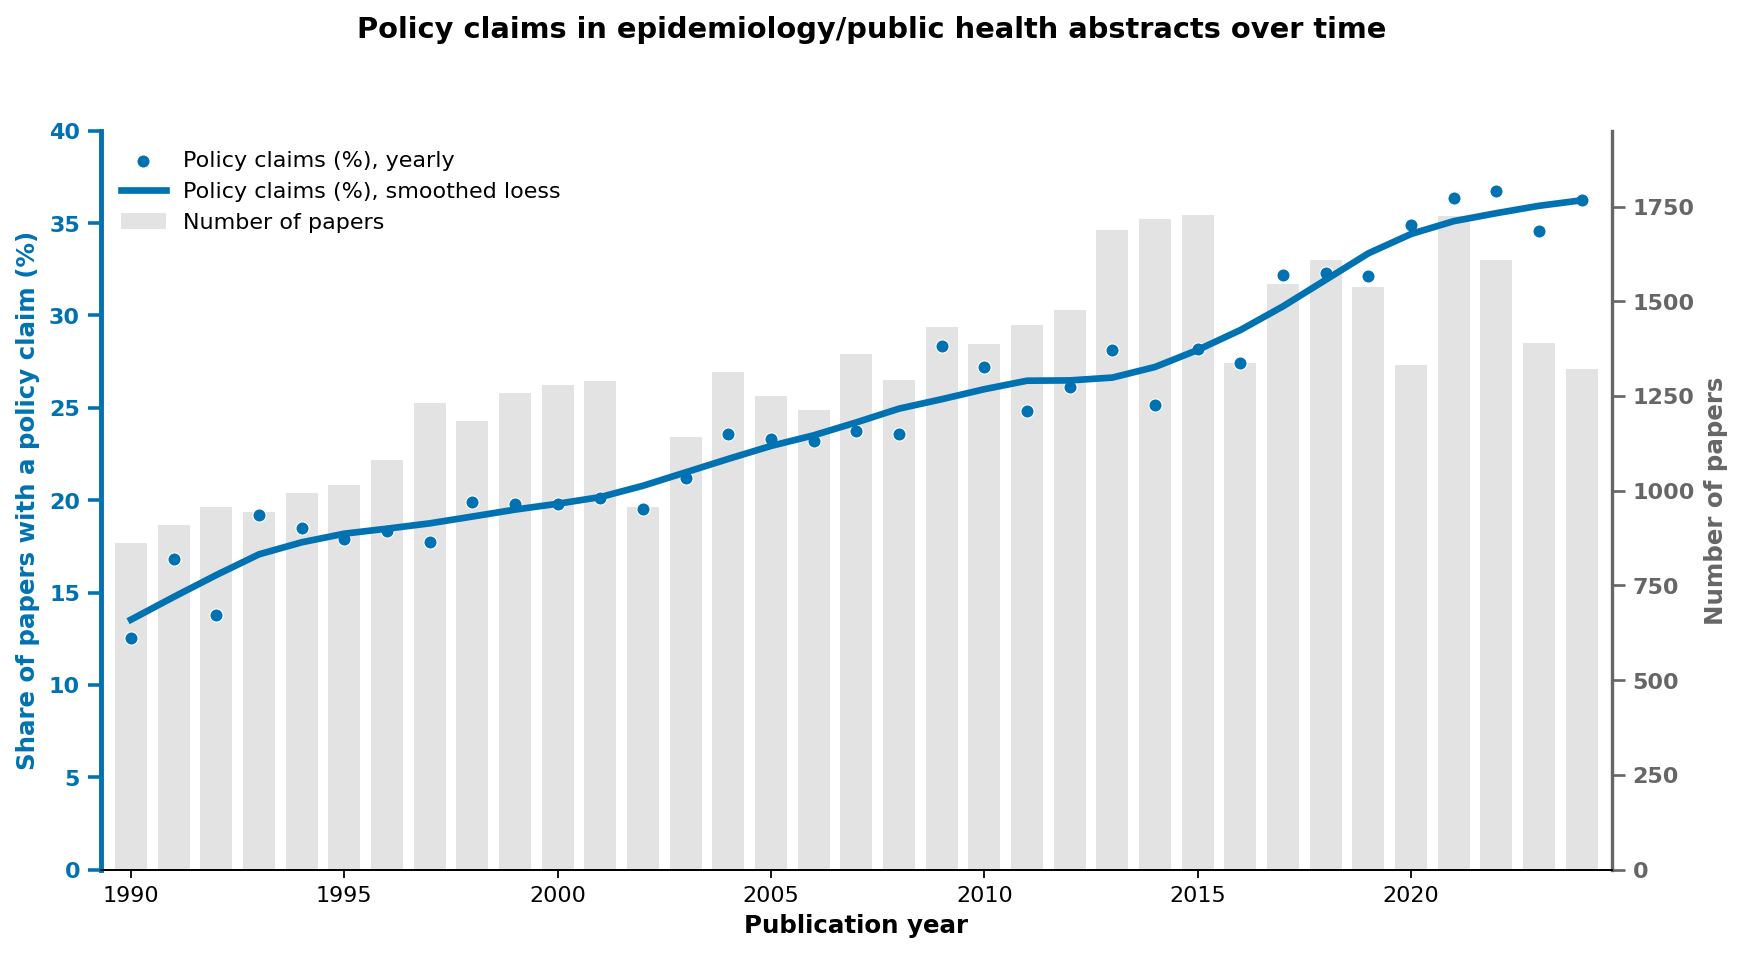

In [46]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- Configuration ----------------
FIGURE_DIR = Path("../figures")
YEAR_COL = "publication_year"
CLAIM_COL = "llm_policy_claim"
YEAR_MIN, YEAR_MAX = 1990, 2024
SAVE_PATH = "../figures/figure1_trend_policy_claims_loess.png"
LOESS_FRAC = 0.25

# ---------------- Prep ----------------
if YEAR_COL not in df.columns or CLAIM_COL not in df.columns:
    raise KeyError(f"Expected columns '{YEAR_COL}' and '{CLAIM_COL}' in df.")

work = df.copy()
work = work[work[YEAR_COL].notna() & work[CLAIM_COL].notna()].copy()

work[YEAR_COL] = pd.to_numeric(work[YEAR_COL], errors="coerce").astype("Int64")
work = work[work[YEAR_COL].notna()].copy()
work[YEAR_COL] = work[YEAR_COL].astype(int)

if work[CLAIM_COL].dtype != bool:
    work[CLAIM_COL] = work[CLAIM_COL].astype(str).str.strip().str.lower().map(
        {"true": True, "1": True, "t": True, "yes": True, "y": True,
         "false": False, "0": False, "f": False, "no": False, "n": False}
    ).fillna(work[CLAIM_COL].astype(bool))

work = work[(work[YEAR_COL] >= YEAR_MIN) & (work[YEAR_COL] <= YEAR_MAX)].copy()

# ---------------- Aggregate by year ----------------
agg = (work
       .groupby(YEAR_COL, dropna=False)[CLAIM_COL]
       .agg(n="count", n_claim="sum")
       .reset_index())

agg["pct_claim"] = np.where(agg["n"] > 0, 100 * agg["n_claim"] / agg["n"], np.nan)

# ---------------- LOESS smoothing ----------------
if agg[YEAR_COL].nunique() > 4:
    agg["pct_claim_smooth"] = lowess(
        endog=agg["pct_claim"],
        exog=agg[YEAR_COL],
        frac=LOESS_FRAC,
        return_sorted=False
    )
else:
    agg["pct_claim_smooth"] = np.nan

# ---------------- Plot ----------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)
ax2 = ax.twinx()

# --- FIX: BRING DOTS/LINES TO FRONT ---
# By default, ax2 (twinx) draws on top of ax. This forces ax to draw on top.
ax.set_zorder(10)
ax.patch.set_visible(False)  # Hide background of ax so the ax2 bars are visible underneath

# Colours
policy_color = "#0072B2"
count_color = "#666666"

# Clean spines
ax.grid(False)
ax2.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Left y-axis strictly uses the exact blue shade
ax.spines["left"].set_color(policy_color)
ax.spines["left"].set_linewidth(2.2)
ax.yaxis.label.set_color(policy_color)
ax.yaxis.label.set_fontweight("medium")
ax.tick_params(axis="y", colors=policy_color, width=1.6, length=6)
ax.yaxis.get_offset_text().set_color(policy_color)

# Right y-axis grey, matching counts
ax2.spines["right"].set_color(count_color)
ax2.spines["right"].set_linewidth(1.5)
ax2.yaxis.label.set_color(count_color)
ax2.tick_params(axis="y", colors=count_color, width=1.2, length=6)
ax2.yaxis.get_offset_text().set_color(count_color)

# Bars: yearly counts (Draws perfectly underneath due to zorder fix above)
bars = ax2.bar(
    agg[YEAR_COL], agg["n"],
    alpha=0.18, width=0.75,
    color=count_color, edgecolor="none",
    label="Number of papers"
 )

# Dots (Restored white edge so the blue shade perfectly matches your image)
ax.scatter(
    agg[YEAR_COL], agg["pct_claim"],
    s=35, color=policy_color, edgecolors="white", linewidth=0.5,
    label="Policy claims (%), yearly"
 )

# LOESS line
ax.plot(
    agg[YEAR_COL], agg["pct_claim_smooth"],
    linewidth=3.0, color=policy_color,
    label="Policy claims (%), smoothed loess"
 )

# Labels
ax.set_xlabel("Publication year", fontsize=11, fontweight="bold")
ax.set_ylabel("Share of papers with a policy claim (%)", fontsize=11, color=policy_color, fontweight="bold")
ax2.set_ylabel("Number of papers", fontsize=11, color=count_color, fontweight="bold")

# Limits
ax.set_xlim(agg[YEAR_COL].min() - 0.7, agg[YEAR_COL].max() + 0.7)

# Precise Y-Axis bounding to match the image visually
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 45, 5))
ax2.set_ylim(0, 1950)
ax2.set_yticks(np.arange(0, 2000, 250))

for tick_label in ax.get_yticklabels():
    tick_label.set_fontweight("bold")

for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight("bold")

# Title
fig.suptitle(
    "Policy claims in epidemiology/public health abstracts over time",
    y=0.96, fontsize=13, fontweight="bold"
 )

# Legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## Fig 1 with manual estimates

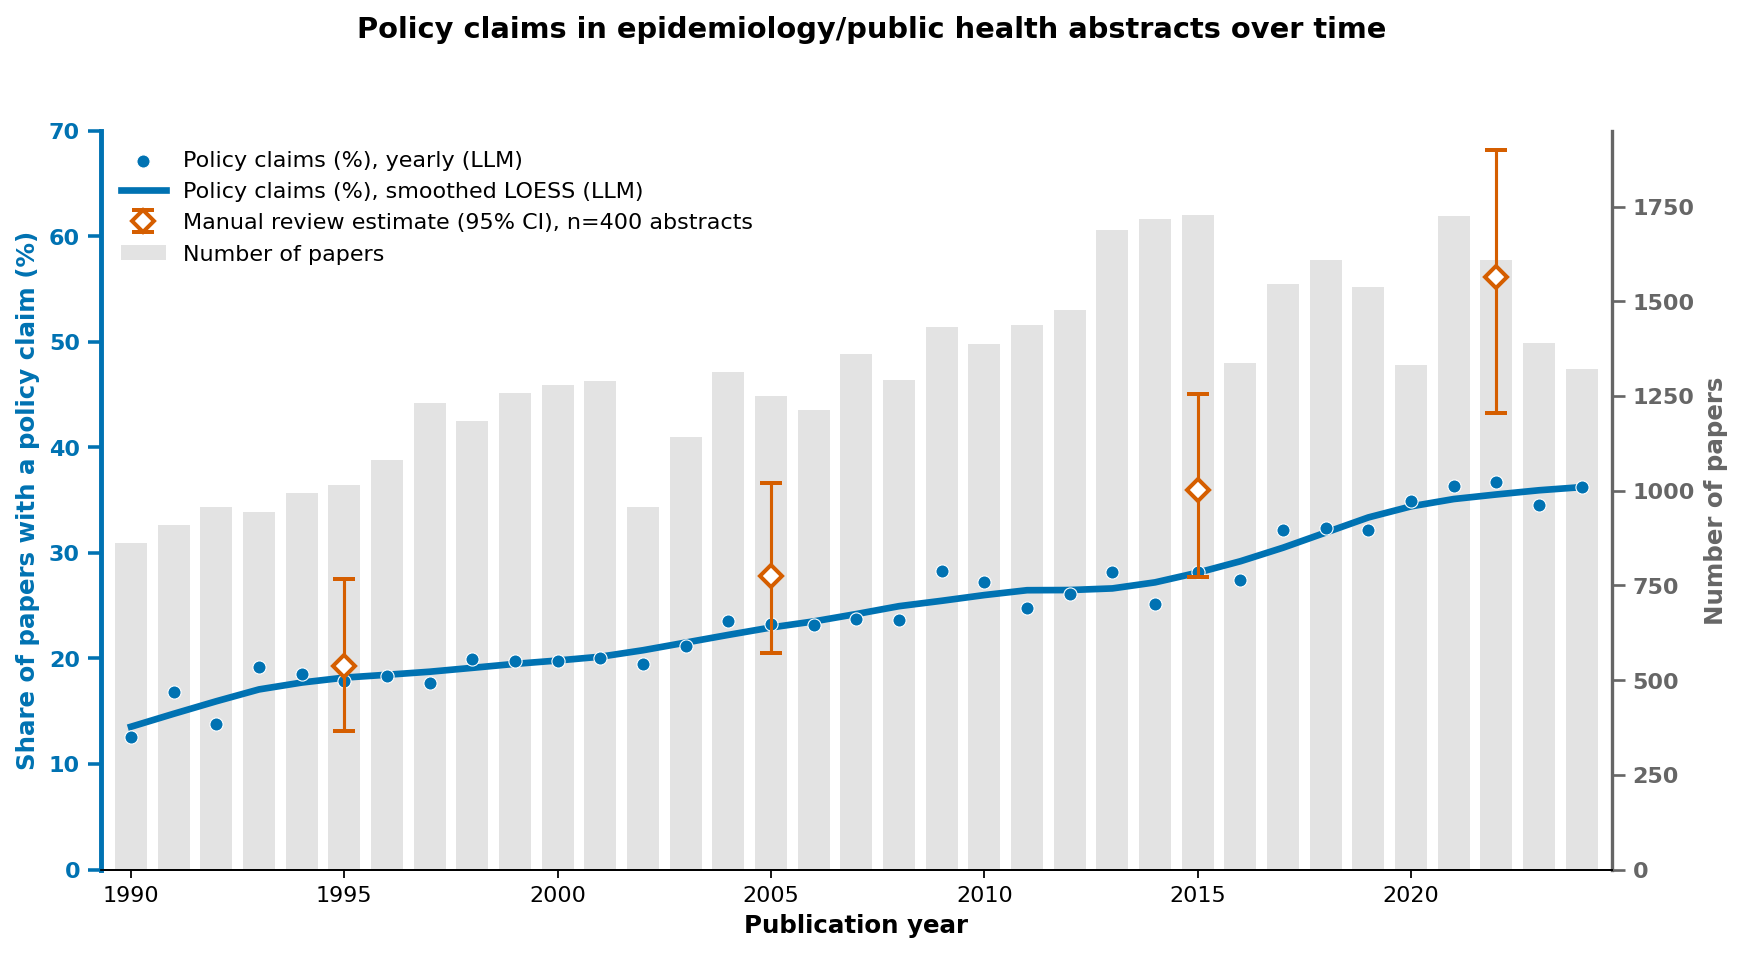

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- Configuration ----------------
FIGURE_DIR = Path("../figures")
YEAR_COL = "publication_year"
CLAIM_COL = "llm_policy_claim"
YEAR_MIN, YEAR_MAX = 1990, 2024
SAVE_PATH = "../figures/figure1_trend_policy_claims_loess.png"
LOESS_FRAC = 0.25

# ---------------- Prep ----------------
if YEAR_COL not in df.columns or CLAIM_COL not in df.columns:
    raise KeyError(f"Expected columns '{YEAR_COL}' and '{CLAIM_COL}' in df.")

work = df.copy()
work = work[work[YEAR_COL].notna() & work[CLAIM_COL].notna()].copy()

work[YEAR_COL] = pd.to_numeric(work[YEAR_COL], errors="coerce").astype("Int64")
work = work[work[YEAR_COL].notna()].copy()
work[YEAR_COL] = work[YEAR_COL].astype(int)

if work[CLAIM_COL].dtype != bool:
    work[CLAIM_COL] = work[CLAIM_COL].astype(str).str.strip().str.lower().map(
        {"true": True, "1": True, "t": True, "yes": True, "y": True,
         "false": False, "0": False, "f": False, "no": False, "n": False}
    ).fillna(work[CLAIM_COL].astype(bool))

work = work[(work[YEAR_COL] >= YEAR_MIN) & (work[YEAR_COL] <= YEAR_MAX)].copy()

# ---------------- Aggregate by year ----------------
agg = (work
       .groupby(YEAR_COL, dropna=False)[CLAIM_COL]
       .agg(n="count", n_claim="sum")
       .reset_index())

agg["pct_claim"] = np.where(agg["n"] > 0, 100 * agg["n_claim"] / agg["n"], np.nan)

# ---------------- LOESS smoothing ----------------
if agg[YEAR_COL].nunique() > 4:
    agg["pct_claim_smooth"] = lowess(
        endog=agg["pct_claim"],
        exog=agg[YEAR_COL],
        frac=LOESS_FRAC,
        return_sorted=False
    )
else:
    agg["pct_claim_smooth"] = np.nan

# ---------------- Manual 400-abstract estimates (Supplementary Table 8) ----------------
manual_estimates = pd.DataFrame([
    {"period": "1990-1999", "midyear": 1995, "n": 114, "k": 22, "est": 19.3, "lo": 13.1, "hi": 27.5},
    {"period": "2000-2009", "midyear": 2005, "n": 115, "k": 32, "est": 27.8, "lo": 20.5, "hi": 36.6},
    {"period": "2010-2019", "midyear": 2015, "n": 114, "k": 41, "est": 36.0, "lo": 27.7, "hi": 45.1},
    {"period": "2020-2024", "midyear": 2022, "n": 57,  "k": 32, "est": 56.1, "lo": 43.3, "hi": 68.2},
])
manual_yerr = np.vstack([
    manual_estimates["est"] - manual_estimates["lo"],
    manual_estimates["hi"] - manual_estimates["est"],
])

# ---------------- Plot ----------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)
ax2 = ax.twinx()

# --- FIX: BRING DOTS/LINES TO FRONT ---
ax.set_zorder(10)
ax.patch.set_visible(False)

# Colours
policy_color = "#0072B2"
count_color = "#666666"
manual_color = "#D55E00"   # dark orange — colorblind-safe contrast to the blue

# Clean spines
ax.grid(False)
ax2.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Left y-axis strictly uses the exact blue shade
ax.spines["left"].set_color(policy_color)
ax.spines["left"].set_linewidth(2.2)
ax.yaxis.label.set_color(policy_color)
ax.yaxis.label.set_fontweight("medium")
ax.tick_params(axis="y", colors=policy_color, width=1.6, length=6)
ax.yaxis.get_offset_text().set_color(policy_color)

# Right y-axis grey, matching counts
ax2.spines["right"].set_color(count_color)
ax2.spines["right"].set_linewidth(1.5)
ax2.yaxis.label.set_color(count_color)
ax2.tick_params(axis="y", colors=count_color, width=1.2, length=6)
ax2.yaxis.get_offset_text().set_color(count_color)

# Bars: yearly counts
bars = ax2.bar(
    agg[YEAR_COL], agg["n"],
    alpha=0.18, width=0.75,
    color=count_color, edgecolor="none",
    label="Number of papers"
)

# LLM yearly dots
ax.scatter(
    agg[YEAR_COL], agg["pct_claim"],
    s=35, color=policy_color, edgecolors="white", linewidth=0.5,
    label="Policy claims (%), yearly (LLM)",
    zorder=4,
)

# LOESS line
ax.plot(
    agg[YEAR_COL], agg["pct_claim_smooth"],
    linewidth=3.0, color=policy_color,
    label="Policy claims (%), smoothed LOESS (LLM)",
    zorder=3,
)

# Manual 400-abstract estimates with 95% CIs
ax.errorbar(
    manual_estimates["midyear"],
    manual_estimates["est"],
    yerr=manual_yerr,
    fmt="D",                    # diamond to distinguish from LLM circles
    color=manual_color,
    ecolor=manual_color,
    elinewidth=1.4,
    capsize=5,
    markersize=7,
    markerfacecolor="white",
    markeredgewidth=1.8,
    zorder=6,
    label="Manual review estimate (95% CI), n=400 abstracts",
)

# Labels
ax.set_xlabel("Publication year", fontsize=11, fontweight="bold")
ax.set_ylabel("Share of papers with a policy claim (%)", fontsize=11, color=policy_color, fontweight="bold")
ax2.set_ylabel("Number of papers", fontsize=11, color=count_color, fontweight="bold")

# Limits
ax.set_xlim(agg[YEAR_COL].min() - 0.7, agg[YEAR_COL].max() + 0.7)

# Y-axis bumped to 70 so the 2020-2024 manual CI upper bound (68.2) is visible
ax.set_ylim(0, 70)
ax.set_yticks(np.arange(0, 75, 10))
ax2.set_ylim(0, 1950)
ax2.set_yticks(np.arange(0, 2000, 250))

for tick_label in ax.get_yticklabels():
    tick_label.set_fontweight("bold")

for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight("bold")

# Title
fig.suptitle(
    "Policy claims in epidemiology/public health abstracts over time",
    y=0.96, fontsize=13, fontweight="bold"
)

# Legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## Policy claim % by country and 5-year period

In [29]:
# Table of % policy claims per country per 5-year period
if 'corresponding_author_country' in df.columns and len(df) > 0:
    # Use the same eligible_countries logic as in the main analysis
    counts_by_country_year = df.groupby(['corresponding_author_country', YEAR_COLUMN]).size().unstack(fill_value=0)
    mean_per_year = counts_by_country_year.mean(axis=1)
    eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != 'UNKNOWN']
    df_eligible = df[df['corresponding_author_country'].isin(eligible_countries)].copy()
    if len(df_eligible) > 0:
        min_year = int(df_eligible[YEAR_COLUMN].min())
        max_year = int(df_eligible[YEAR_COLUMN].max())
        bins = list(range(min_year, max_year + 5, 5))
        labels = [f"{y}-{y+4}" for y in bins[:-1]]
        df_eligible['year_period'] = pd.cut(df_eligible[YEAR_COLUMN], bins=bins, labels=labels, right=True, include_lowest=True)
        period_country = (
            df_eligible.groupby(['corresponding_author_country', 'year_period'])['claim']
            .mean()
            .unstack()
        )
        period_country = period_country.loc[eligible_countries]  # keep order
        period_country = period_country * 100  # convert to percent
        period_country = period_country.round(1)
        # Sort by most recent period (last column)
        if period_country.shape[1] > 0:
            period_country = period_country.sort_values(by=period_country.columns[-1], ascending=False)
        display(period_country)
    else:
        print('No eligible country data for 5-year period table.')
else:
    print('No corresponding_author_country column or data.')

/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_20646/82386958.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eligible.groupby(['corresponding_author_country', 'year_period'])['claim']


year_period,1990-1994,1995-1999,2000-2004,2005-2009,2010-2014,2015-2019,2020-2024
corresponding_author_country,,,,,,,
AUSTRALIA,18.8,26.5,24.7,29.0,29.0,30.2,42.9
ITALY,8.3,19.4,18.2,25.3,37.2,36.2,42.9
UNITED STATES,16.9,20.2,23.1,26.8,28.7,33.6,38.1
NETHERLANDS,13.2,15.3,26.8,19.2,23.7,28.3,36.7
SPAIN,12.0,20.6,22.6,26.7,24.4,28.9,35.5
CANADA,15.3,19.2,18.1,29.8,25.2,35.7,34.3
UNITED KINGDOM,16.4,18.0,18.7,27.7,22.6,29.8,34.0
CHINA,8.7,16.7,17.1,22.7,20.4,24.6,33.6
FRANCE,13.1,18.3,22.6,18.9,20.0,36.1,31.7


In [186]:
doc = Document()
t = doc.add_table(rows=1, cols=period_country.shape[1]+1, style="Table Grid")
hdr = ["Country"] + [str(c) for c in period_country.columns]
for j,h in enumerate(hdr): t.rows[0].cells[j].paragraphs[0].add_run(h).bold = True
for country, row in period_country.iterrows():
    cells = t.add_row().cells
    p0 = cells[0].paragraphs[0]; p0.add_run(str(country)); p0.alignment = WD_ALIGN_PARAGRAPH.LEFT
    for j,v in enumerate(row.tolist(), start=1):
        p = cells[j].paragraphs[0]; p.add_run("" if pd.isna(v) else f"{v:.1f}"); p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
t.alignment = WD_TABLE_ALIGNMENT.CENTER
doc.save("../table/table1b_Policy Claim Percentage by Country and 5-Year Period.docx")

## Fig 2: Country comparison slopegraph

*Figure 2. Policy claims by country, 1990–2024*

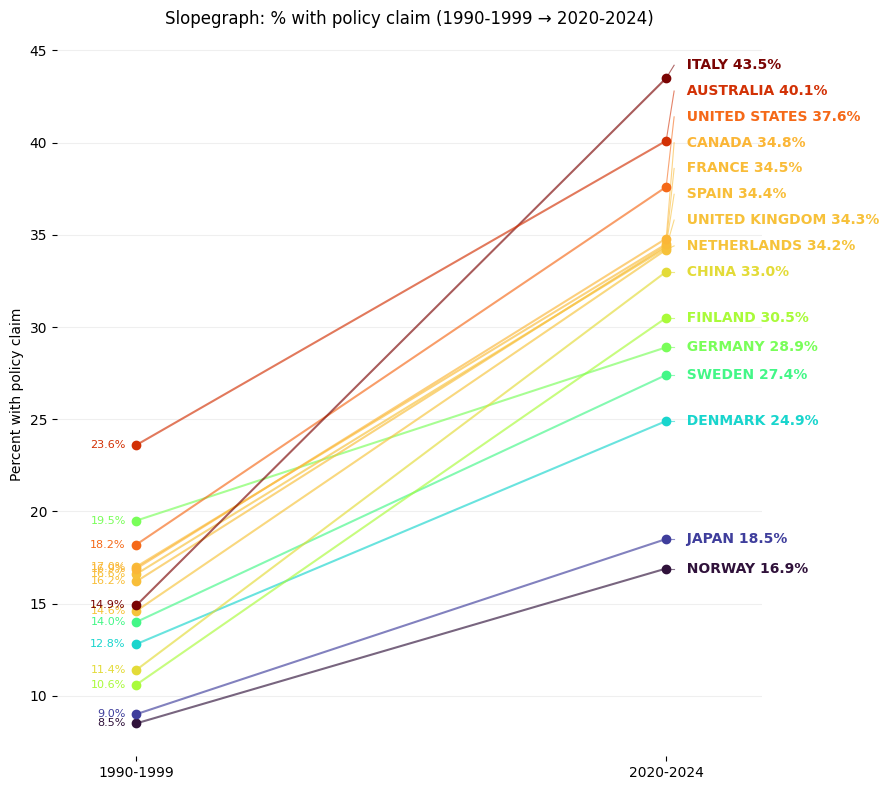

In [142]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

# --- Extract the country rows from your table1 ---
# (they start after the 'Countries' row)
country_start = row_names.index('Countries (first author), policy claim rate (%)') + 1
country_rows = row_names[country_start:]

# Make a new dataframe containing just those countries and numeric values
period_country = (
    table1.loc[country_rows, [c for c in table1.columns if c in periods.keys()]]
    .applymap(lambda x: np.nan if isinstance(x, str) and not x.replace('.', '', 1).isdigit() else x)
    .astype(float)
)

# Drop any rows or columns with missing values
period_country = period_country.dropna(how="all", axis=0).dropna(how="all", axis=1)

# --- Prepare columns for slopegraph ---
start_col = '1990-1999'
end_col = '2020-2024'

if start_col not in period_country.columns:
    start_col = period_country.columns[0]
if end_col not in period_country.columns:
    end_col = period_country.columns[-1]

data = period_country[[start_col, end_col]].copy()
data = data.dropna()

# Remove 'Unknown' or blank countries
data = data[~data.index.str.lower().str.contains('unknown')]

# --- Sort to reduce line crossings ---
order_score = 0.3 * data[start_col] + 0.7 * data[end_col]
data = data.loc[order_score.sort_values().index]

# --- Assign colors based on END value ---
end_values = data[end_col].values
norm_values = (end_values - end_values.min()) / (end_values.max() - end_values.min())
colors = cm.turbo(norm_values)
country_colors = dict(zip(data.index, colors))

# --- Compute non-overlapping y label positions ---
y_end_true = data[end_col].to_numpy(dtype=float)
min_gap = 1.4  # label spacing in percentage points
idx = np.argsort(y_end_true)
y_lab = y_end_true.copy()
for i in range(1, len(idx)):
    j, k = idx[i], idx[i-1]
    if y_lab[j] - y_lab[k] < min_gap:
        y_lab[j] = y_lab[k] + min_gap

y_label_pos = dict(zip(data.index[idx], y_lab[idx]))

y_end_true = data[end_col].to_numpy(dtype=float)
min_gap_right = 1.4
idxR = np.argsort(y_end_true)
y_lab_right = y_end_true.copy()
for i in range(1, len(idxR)):
    j, k = idxR[i], idxR[i-1]
    if y_lab_right[j] - y_lab_right[k] < min_gap_right:
        y_lab_right[j] = y_lab_right[k] + min_gap_right
y_label_pos_right = dict(zip(data.index[idxR], y_lab_right[idxR]))

# --- Plot the slopegraph ---
fig_h = max(8, 0.18 * len(data))
fig, ax = plt.subplots(figsize=(9, fig_h))
x0, x1 = 0.0, 1.0

for cty, row in data.iterrows():
    y0, y1 = float(row[start_col]), float(row[end_col])
    y1_lab = float(y_label_pos[cty])
    color = country_colors[cty]

    # line and points
    ax.plot([x0, x1], [y0, y1], linewidth=1.5, alpha=0.65, color=color)
    ax.scatter([x0, x1], [y0, y1], s=36, zorder=3, color=color)

    # text labels - LEFT SIDE NOW USES SAME COLOR
    ax.text(x0 - 0.02, y0, f"{y0:.1f}%", ha="right", va="center", fontsize=8, color=color)
    ax.plot([x1, x1 + 0.015], [y1, y1_lab], linewidth=0.8, alpha=0.6, color=color)
    ax.text(x1 + 0.02, y1_lab, f"{cty.upper()} {y1:.1f}%", ha="left", va="center",
            fontsize=10, fontfamily="sans-serif", fontweight="bold", color=color)

# Cosmetics
ax.set_xlim(-0.15, 1.18)
ax.set_xticks([x0, x1])
ax.set_xticklabels([start_col, end_col])
ax.set_ylabel("Percent with policy claim")
ax.set_title(f"Slopegraph: % with policy claim ({start_col} → {end_col})")
ax.grid(axis='y', alpha=0.2, linewidth=0.8)
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure2_slopegraph_policy_claims.png")
plt.show()

## Fig 3: Policy claims by journal (absolute and relative)

*Figure 3. Policy claims by journal: absolute counts (top) and relative percentage (bottom)*

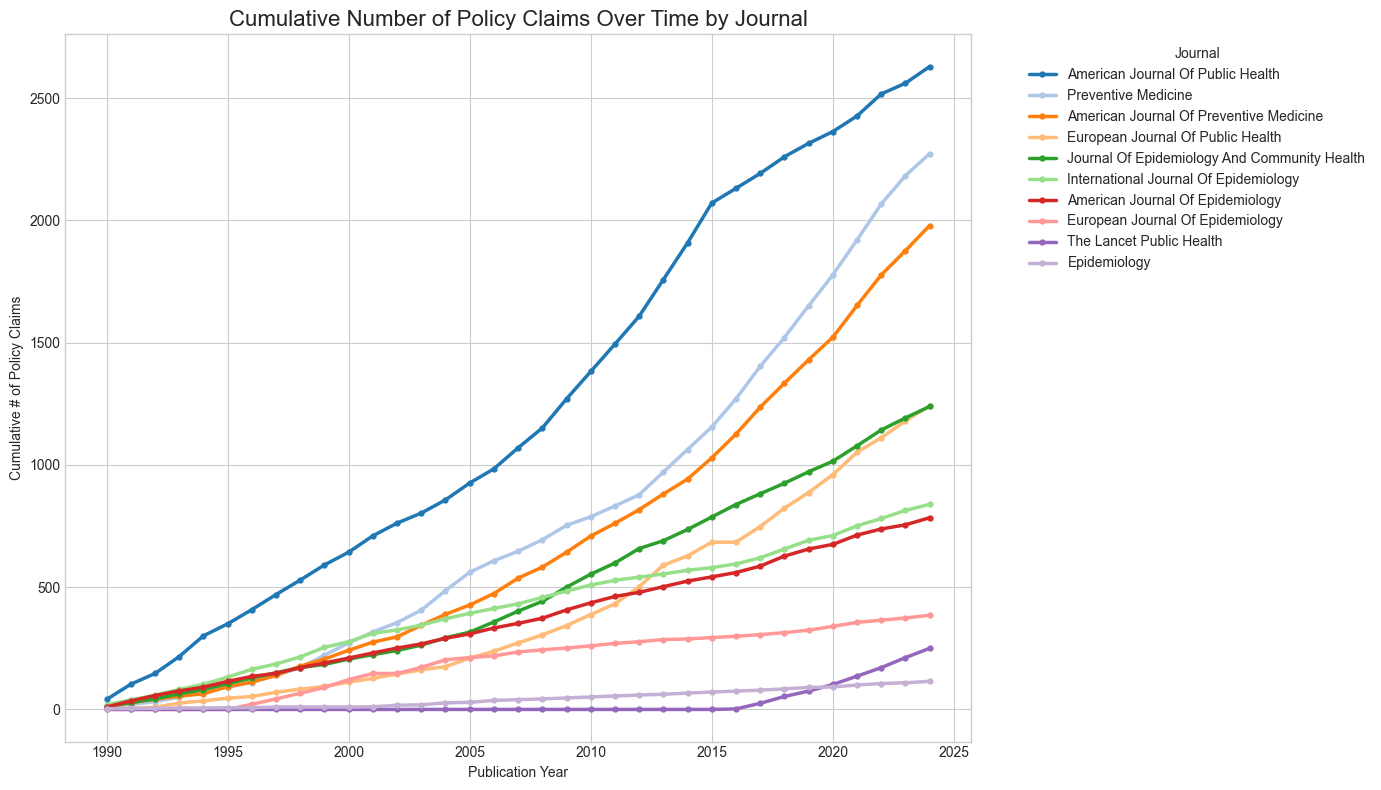

In [184]:
# TOP - Absolute Trends

# This plot shows the total count of policy claims accumulating over time for each of the top journals. 
# This is useful for seeing which journals have produced the largest absolute number of claims. We will plot the top 15 journals to keep the visualization clean.

# Group by year and journal, count claims, and then calculate the cumulative sum for all journals
cumulative_counts = (
    df.groupby([YEAR_COLUMN, JOURNAL_COLUMN])['claim']
    .sum()
    .unstack(fill_value=0)
    .cumsum()
)

# Sort columns (journals) by their final cumulative value descending
final_order = cumulative_counts.iloc[-1].sort_values(ascending=False).index
cumulative_counts = cumulative_counts[final_order]

palette = (sns.color_palette("tab20", n_colors=len(final_order))
           if len(final_order) <= 20 else sns.color_palette("hls", n_colors=len(final_order)))
journal_colors = dict(zip(final_order, palette))

# Create the plot
plt.figure(figsize=(14, max(8, 0.4*len(final_order))))
ax = cumulative_counts.plot(
    ax=plt.gca(),
    marker='o', linestyle='-',
    linewidth=2.5,            
    markersize=3.5,             
    color=[journal_colors[j] for j in final_order]
)

plt.title('Cumulative Number of Policy Claims Over Time by Journal', fontsize=16)
plt.ylabel('Cumulative # of Policy Claims')
plt.xlabel('Publication Year')
plt.legend(title='Journal', bbox_to_anchor=(1.05, 1), loc='upper left', labels=final_order)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure3_top_cumulative_absolute_by_journal.png")
plt.show() 


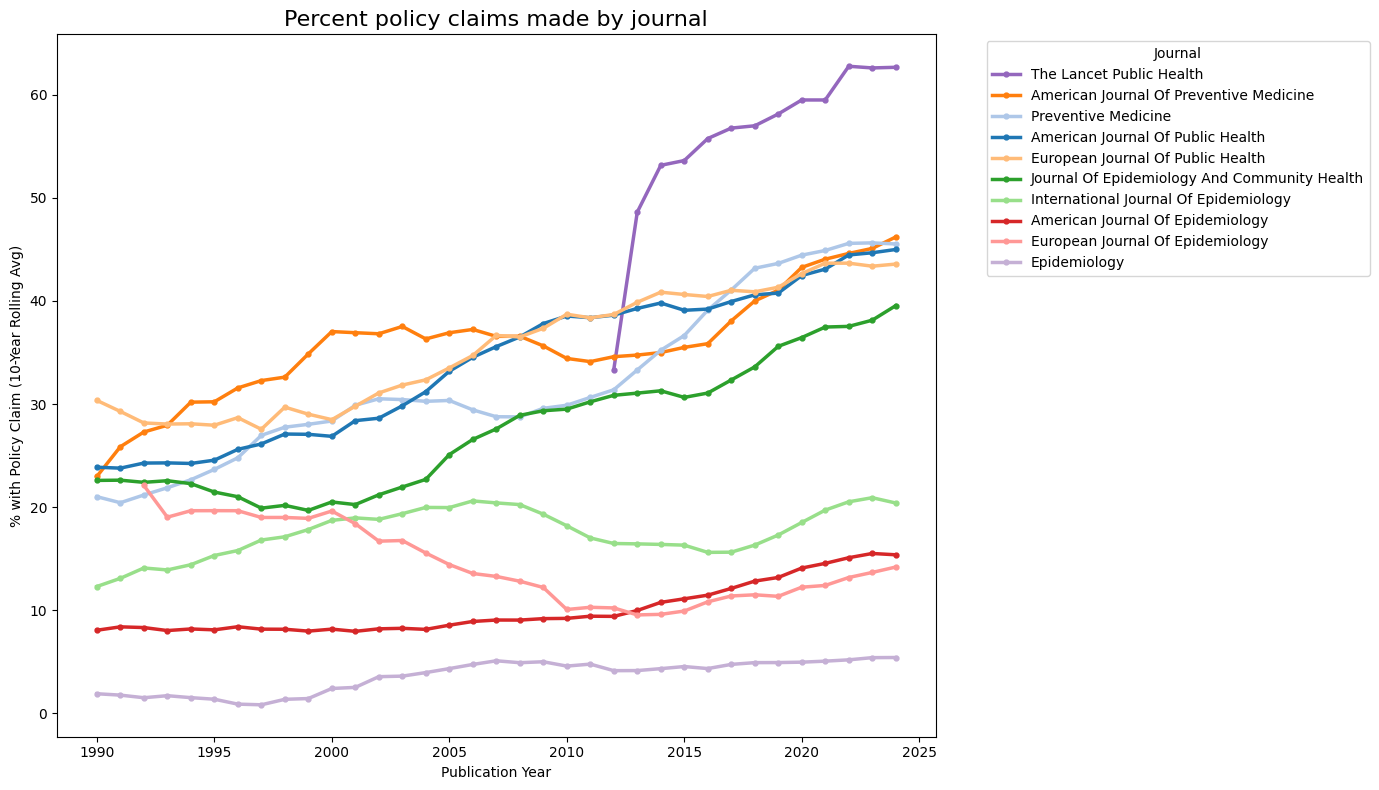

In [ ]:
# BOTTOM  - Relative Trends: Percentage (%) of Claims per Year

# This plot shows the annual percentage of articles with policy claims. 
# This view is great for spotting year-to-year variability and recent changes in a journal's focus.

# Mean claim rate by journal and year (%)
yearly_percent_df = (
    df.groupby([YEAR_COLUMN, JOURNAL_COLUMN])['claim']
      .mean()
      .mul(100)
      .reset_index(name='percent_claim')
)

# 10 year centered rolling average
pivoted_df = yearly_percent_df.pivot(index=YEAR_COLUMN, columns=JOURNAL_COLUMN, values='percent_claim')

# ensure a continuous year index
year_idx = pd.RangeIndex(pivoted_df.index.min(), pivoted_df.index.max() + 1)
pivoted_df = pivoted_df.reindex(year_idx)

rolling_avg_df = pivoted_df.rolling(window=10, min_periods=1, center=True).mean()

# Order journals by their 2024 values (highest to lowest)
if 2024 in rolling_avg_df.index:
    values_2024 = rolling_avg_df.loc[2024].dropna().sort_values(ascending=False)
    legend_order = values_2024.index.tolist()
else:
    # fallback to last year if 2024 not available
    values_last = rolling_avg_df.iloc[-1].dropna().sort_values(ascending=False)
    legend_order = values_last.index.tolist()

# Reorder columns
rolling_avg_df = rolling_avg_df[legend_order]

# Plot with pandas/matplotlib to keep style consistent with the cumulative figure
plt.figure(figsize=(14, max(8, 0.4*len(legend_order))))
ax = rolling_avg_df.plot(
    ax=plt.gca(),
    marker='o', linestyle='-',
    linewidth=2.5,
    markersize=3.5,
    color=[journal_colors[j] for j in legend_order]
)

plt.title('Percent policy claims made by journal', fontsize=16)
plt.ylabel('% with Policy Claim (10-Year Rolling Avg)')
plt.xlabel('Publication Year')
plt.legend(title='Journal', bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_order)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure3_bottom_yearly_percent_by_journal_smoothed.png")
plt.show()



## Fig 4: Policy claims by study design

*Policy claim rates by study design (upper and right panels), and tabulations of study design by year (left)*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# design_strict, design_keywords, and design_combined are already computed
# by 5_add_study_design_and_topics.py and loaded once above from ANALYSIS_DATA_FILE.
# No re-derivation needed here.

df = df[df['llm_policy_claim'].notna()].copy()
df['llm_policy_claim'] = df['llm_policy_claim'].astype(bool)

def summarize_and_prepare(df_in, design_col_name):
    df_filtered = df_in[df_in[design_col_name] != 'Other/None'].copy()
    summary = (
        df_filtered.groupby(design_col_name)['llm_policy_claim']
        .agg(policy_claim_pct=lambda s: 100 * s.mean(), n_articles='size')
        .reset_index()
    )
    order = ['Experimental', 'Quasi-experimental', 'Cohort', 'Cross-sectional',
             'Ecological / Time-series', 'Case-control', 'Qualitative']
    summary[design_col_name] = pd.Categorical(summary[design_col_name], categories=order, ordered=True)
    summary = summary.sort_values(design_col_name).rename(columns={design_col_name: 'study_design_group'})
    excluded_count = len(df_in) - len(df_filtered)
    return summary, excluded_count

summary_strict,    excluded_strict    = summarize_and_prepare(df, 'design_strict')
summary_keywords,  excluded_keywords  = summarize_and_prepare(df, 'design_keywords')
summary_combined,  excluded_combined  = summarize_and_prepare(df, 'design_combined')

# --- Plot ---
plt.figure(figsize=(10.5, 5.8))
x = np.arange(len(summary_combined))
y = summary_combined['policy_claim_pct'].values
labels = summary_combined['study_design_group'].astype(str).tolist()

plt.bar(x, y)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('% with policy claim')
plt.xlabel('Study Design')
plt.title('Policy Claim Rate by Study Design')
plt.grid(False)

for xi, yi, n in zip(x, y, summary_combined['n_articles'].values):
    pad = max(1, 0.02 * (max(y) if len(y) and max(y) > 0 else 50))
    plt.text(xi, yi + pad, f"n={int(n)}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, (max(y) if len(y) else 0) * 1.20 + 5)
plt.tight_layout()

# --- Tables ---
print('\n' + '='*80)
print('SUMMARY TABLES')
print('='*80)

print('\n--- Main Results: Combined Method (Strict with Keyword Fallback) ---')
print(f"Total articles classified: {summary_combined['n_articles'].sum()} / {len(df)}")
print(f"Excluded {excluded_combined} articles ({excluded_combined/len(df)*100:.1f}%)")
print(summary_combined.to_string(index=False))

print('\n\n--- Sensitivity Analysis: Strict (Title/Abstract) vs. Keywords ---')
comparison_table = pd.merge(summary_strict, summary_keywords, on='study_design_group',
                             how='outer', suffixes=('_strict', '_keywords'))
numeric_cols = comparison_table.columns.drop('study_design_group')
comparison_table[numeric_cols] = comparison_table[numeric_cols].fillna(0)
comparison_table['Strict (Title/Abstract)'] = comparison_table.apply(
    lambda row: f"{row['policy_claim_pct_strict']:.1f}% (n={int(row['n_articles_strict'])})", axis=1)
comparison_table['Keywords'] = comparison_table.apply(
    lambda row: f"{row['policy_claim_pct_keywords']:.1f}% (n={int(row['n_articles_keywords'])})", axis=1)
final_table = comparison_table[['study_design_group', 'Strict (Title/Abstract)', 'Keywords']]
print(f"Strict method classified {len(df) - excluded_strict} articles. "
      f"Keyword method classified {len(df) - excluded_keywords} articles.")
print(final_table.to_string(index=False))

plt.savefig(FIGURE_DIR / 'figure4_upper_policy_claim_rate_by_study_design.png')
plt.show()


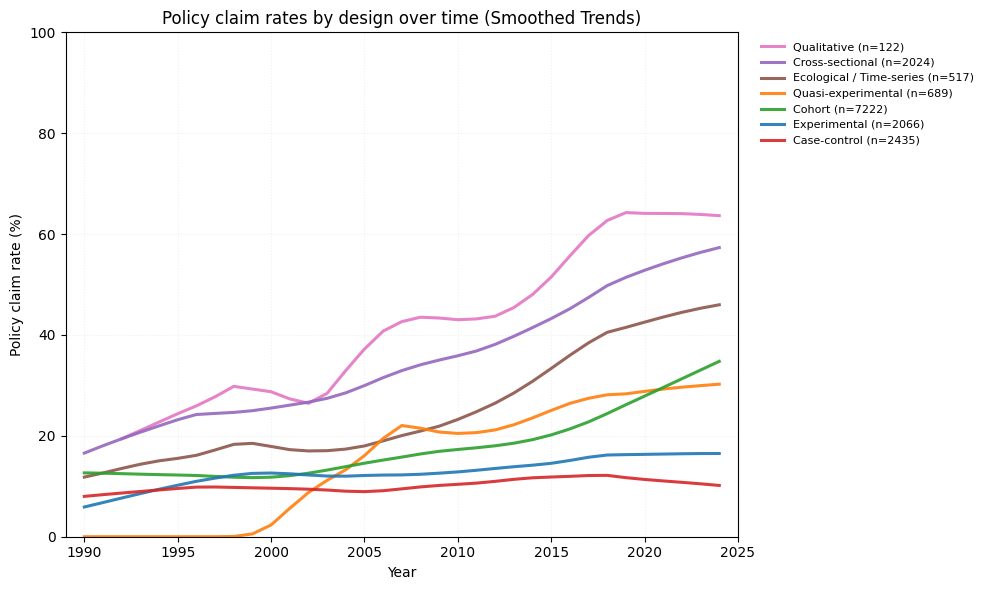

In [50]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Consistent colours for each study design category
fixed_color_map = {
    'Experimental':           '#1f77b4',
    'Quasi-experimental':     '#ff7f0e',
    'Cohort':                 '#2ca02c',
    'Case-control':           '#d62728',
    'Cross-sectional':        '#9467bd',
    'Ecological / Time-series': '#8c564b',
    'Qualitative':            '#e377c2',
}

# Exclude 'Other/None' from these plots.
df_filtered = df[df['design_combined'] != 'Other/None'].copy()

YEAR_COL   = "publication_year"
DESIGN_COL = "design_combined"
CLAIM_COL  = "llm_policy_claim"


yearly_counts = (
    df_filtered.groupby([YEAR_COL, DESIGN_COL])
    .size().reset_index(name="n_articles")
)
yearly_rates = (
    df_filtered.groupby([YEAR_COL, DESIGN_COL])[CLAIM_COL]
    .mean().mul(100).reset_index(name="rate")
)

rates_p = yearly_rates.pivot(index=YEAR_COL, columns=DESIGN_COL, values="rate")
counts_p = yearly_counts.pivot(index=YEAR_COL, columns=DESIGN_COL, values="n_articles").fillna(0)

# legend/order by the most recent available rate
recent = {d: (rates_p[d].dropna().iloc[-1] if d in rates_p else -np.inf) for d in rates_p.columns}
ordered = sorted(recent, key=recent.get, reverse=True)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for d in ordered:
    if d not in rates_p: 
        continue
    y = rates_p[d].dropna()
    if len(y) < 3:
        continue
    years = y.index.values
    vals  = y.values
    n_tot = counts_p[d].reindex(y.index).sum()

    try:
        frac = max(0.25, min(0.4, 15/len(y)))
        sm = lowess(vals, years, frac=frac, return_sorted=True)
        ax.plot(sm[:, 0], sm[:, 1], linewidth=2.2, alpha=0.9,
                color=fixed_color_map.get(d), label=f"{d} (n={int(n_tot)})")
    except Exception:
        ax.plot(years, vals, linewidth=1.8, alpha=0.85,
                color=fixed_color_map.get(d), label=f"{d} (n={int(n_tot)})")

ax.set_xlim(rates_p.index.min()-1, rates_p.index.max()+1)
ax.set_ylim(0, 100)
ax.set_xlabel("Year"); ax.set_ylabel("Policy claim rate (%)")
ax.set_title("Policy claim rates by design over time (Smoothed Trends)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
ax.grid(True, alpha=0.2, linestyle=":")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure4_right_panel_policy_claim_rates_by_design_over_time_smoothed.png")
plt.show() 

# --- Build 5-year band pivot for heatmap (cell 41) ---
PERIOD_BINS  = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
PERIOD_LABELS = ['1990-94','1995-99','2000-04','2005-09','2010-14','2015-19','2020-24']

tmp = df_filtered[[YEAR_COL, DESIGN_COL]].copy()
tmp['period'] = pd.cut(tmp[YEAR_COL], bins=PERIOD_BINS, labels=PERIOD_LABELS, right=False)
temporal_pivot = (
    tmp.groupby(['period', DESIGN_COL], observed=True)
    .size().unstack(fill_value=0)
)
available = [d for d in [
    'Experimental','Quasi-experimental','Cohort','Case-control',
    'Cross-sectional','Ecological / Time-series','Qualitative',
] if d in temporal_pivot.columns]

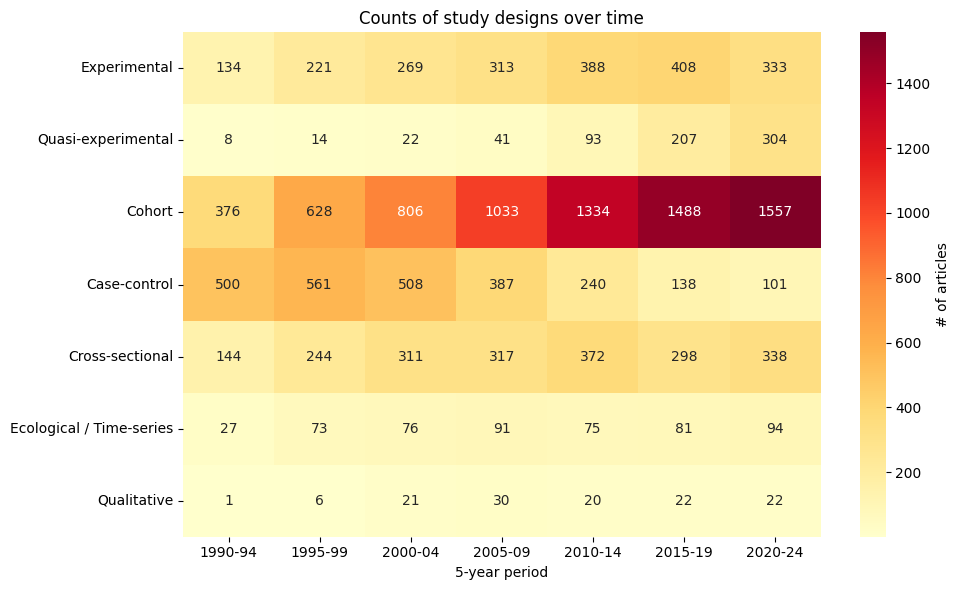

In [51]:
import seaborn as sns
ct = temporal_pivot[available].fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct.T, cmap="YlOrRd", annot=True, fmt=".0f", cbar_kws={"label":"# of articles"}, ax=ax)
ax.set_xlabel("5-year period"); ax.set_ylabel(""); ax.set_title("Counts of study designs over time")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure4_left_panel_counts_of_study_design_over_time_heatmap.png")
plt.show() 

## Fig 5: Policy claims by keyword/topic


TABLE 1: MOST COMMON KEYWORDS (Left Panel)
               Keyword  Total Papers  Policy Claims  No Policy Claims  Policy Claim Rate (%)
               Tobacco          1938            507              1431                   26.2
             Mortality          1674            265              1409                   15.8
     Physical Activity          1531            388              1143                   25.3
               Obesity          1271            284               987                   22.3
          Epidemiology          1214            265               949                   21.8
          Risk Factors          1162            215               947                   18.5
Cardiovascular Disease          1096            170               926                   15.5
        Cohort Studies          1001             96               905                    9.6
 Epidemiologic Methods           843             33               810                    3.9
             Pregnancy    

/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_20646/3727953271.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


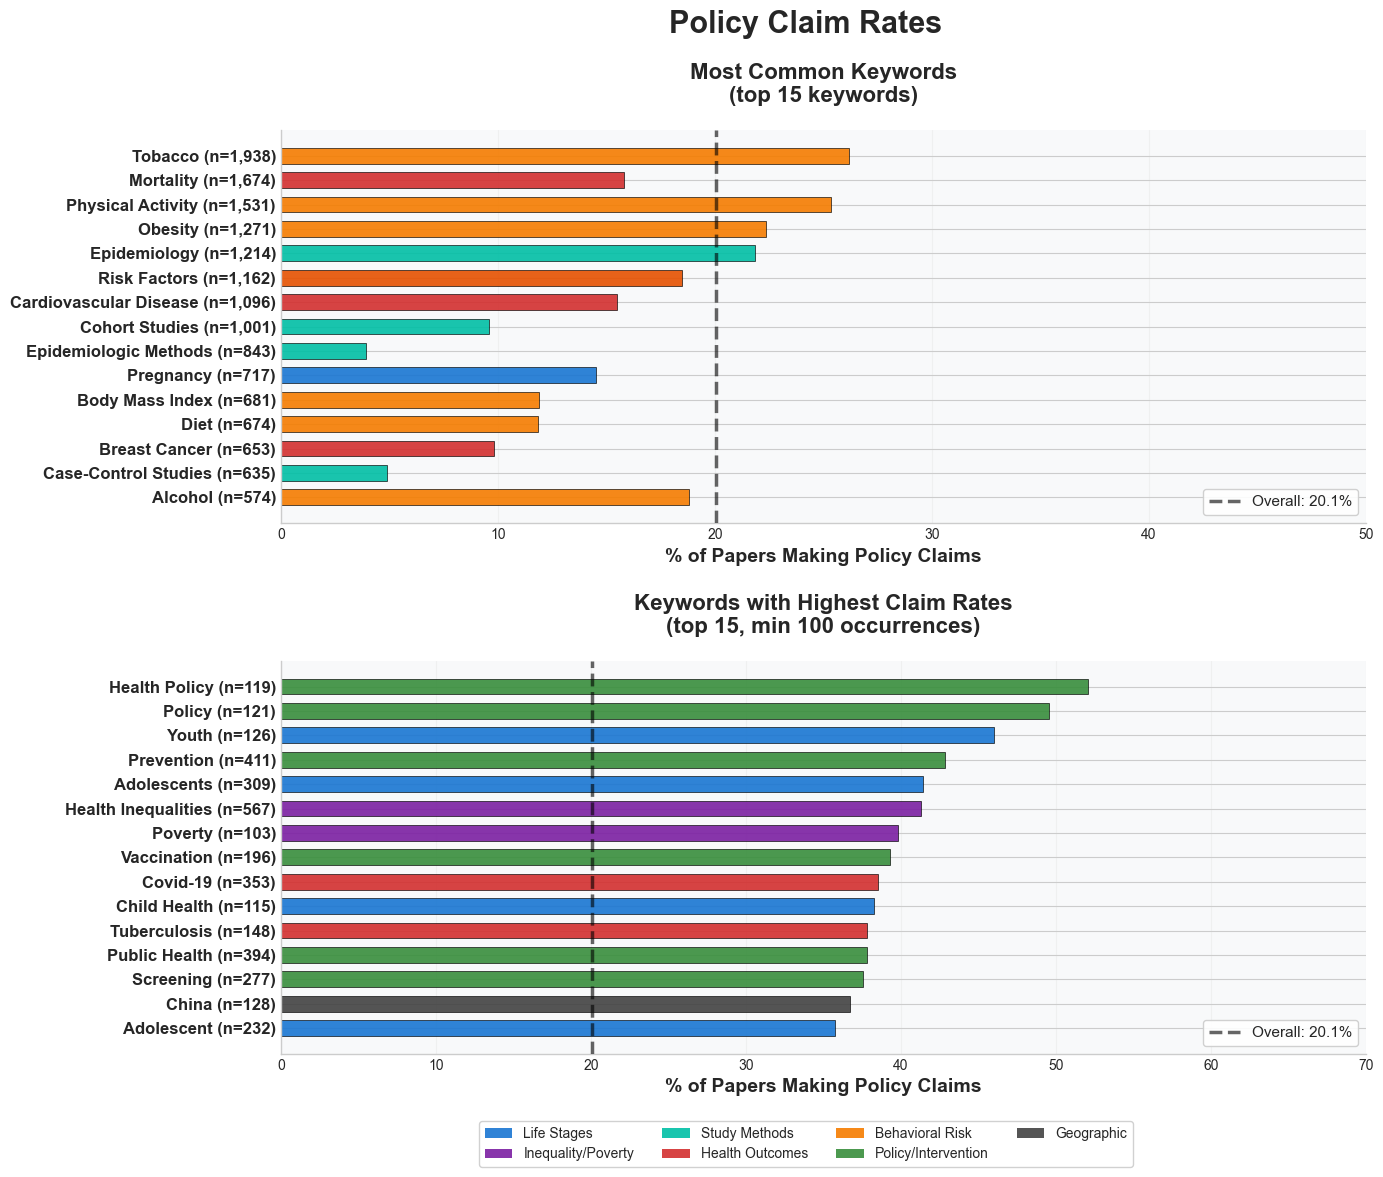

In [33]:
# Keyword Analysis and Visualization
# Keyword Analysis and Visualization (Optimised Colours)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import re
import pandas as pd
from matplotlib.patches import Patch

# --- PLOT SETUP ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 12))  
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)  
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]
fig.suptitle('Policy Claim Rates', fontsize=22, fontweight='bold', y=0.98)

# --- KEYWORD PROCESSING ---
def process_keywords(keyword_data):
    """Extract and clean keywords from semicolon-separated string or list."""
    if isinstance(keyword_data, (list, tuple)):
        parts = keyword_data
    elif pd.isna(keyword_data):
        return []
    else:
        s = str(keyword_data).strip()
        if s in ('', '[]', '[ ]'):
            return []
        parts = [k.strip().strip("'\" ") for k in s.split(';')]
    return [k.lower().strip() for k in parts if k.strip() and len(k.strip()) > 1]


# --- CONSOLIDATION MAPPING ---
keyword_mapping = {
    # Health inequalities cluster
    'health inequalities': 'health inequalities',
    'health disparities': 'health inequalities',
    'disparities': 'health inequalities',
    'social inequalities': 'health inequalities',
    'inequalities': 'health inequalities',
    'healthcare disparities': 'health inequalities',

    # Tobacco cluster (under Behavioral Risk)
    'tobacco use': 'tobacco',
    'tobacco control': 'tobacco',
    'smoking': 'tobacco',
    'cigarette smoking': 'tobacco',

    # Violence cluster
    'domestic violence': 'domestic violence',
    'intimate partner violence': 'domestic violence',
    'partner violence': 'domestic violence',
    'family violence': 'domestic violence',
    'spouse abuse': 'domestic violence',

    # Physical activity cluster
    'physical activity': 'physical activity',
    'exercise': 'physical activity',
    'motor activity': 'physical activity',

    # Obesity cluster
    'obesity': 'obesity',
    'overweight': 'obesity',

    # Cancer types
    'breast neoplasms': 'breast cancer',
    'breast cancer': 'breast cancer',
    'colorectal neoplasms': 'colorectal cancer',
    'colorectal cancer': 'colorectal cancer',
    'lung neoplasms': 'lung cancer',
    'lung cancer': 'lung cancer',
    'cervical cancer': 'cervical cancer',
    'cervical neoplasms': 'cervical cancer',

    # Cardiovascular
    'cardiovascular diseases': 'cardiovascular disease',
    'cardiovascular disease': 'cardiovascular disease',
    'heart disease': 'cardiovascular disease',
    'coronary disease': 'cardiovascular disease',

    # Diabetes
    'diabetes mellitus': 'diabetes',
    'diabetes': 'diabetes',

    # Mental health
    'mental health': 'mental health',
    'mental disorders': 'mental health',
    'depression': 'depression',
    'depressive disorder': 'depression',

    # Alcohol
    'alcohol drinking': 'alcohol',
    'alcoholism': 'alcohol',
    'alcohol': 'alcohol',
}

# --- OPTIMISED COLOUR SCHEME (Swapped life stages and study methods) ---
keyword_colors = {
    # Life stages – NOW Bright blue (was study methods color)
    'child': '#1976D2',
    'adolescent': '#1976D2',
    'adolescents': '#1976D2',
    'youth': '#1976D2',
    'pregnancy': '#1976D2',
    'aged': '#1976D2',
    'child health': '#1976D2',

    # Inequality/socioeconomic – Deep purple
    'health inequalities': '#7B1FA2',
    'poverty': '#7B1FA2',

    # Study methods – NOW Vibrant teal (was life stages color)
    'epidemiology': '#00BFA5',
    'cohort studies': '#00BFA5',
    'case-control studies': '#00BFA5',
    'epidemiologic methods': '#00BFA5',
    'cohort study': '#00BFA5',
    'surveillance': '#00BFA5',

    # Health outcomes – Bright red
    'mortality': '#D32F2F',
    'morbidity': '#D32F2F',
    'incidence': '#D32F2F',
    'cardiovascular disease': '#D32F2F',
    'diabetes': '#D32F2F',
    'breast cancer': '#D32F2F',
    'cervical cancer': '#D32F2F',
    'tuberculosis': '#D32F2F',
    'covid-19': '#D32F2F',

    # Behavioral risk – Orange
    'obesity': '#F57C00',
    'physical activity': '#F57C00',
    'diet': '#F57C00',
    'body mass index': '#F57C00',
    'tobacco': '#F57C00',
    'smoking': '#F57C00',
    'alcohol': '#F57C00',

    # Policy/intervention – Forest green
    'prevention': '#388E3C',
    'screening': '#388E3C',
    'vaccination': '#388E3C',
    'health policy': '#388E3C',
    'policy': '#388E3C',
    'public health': '#388E3C',

    # Geographic – Dark gray
    'china': '#424242',
    'europe': '#424242',
    'canada': '#424242',

    # Violence – Deep burgundy
    'violence': '#922b21',
    'domestic violence': '#922b21',

    # Risk – Dark amber
    'risk factors': '#E65100',
}

def get_keyword_color(keyword):
    """Return color for keyword based on theme, or default gray"""
    return keyword_colors.get(keyword.lower(), '#95a5a6')

def consolidate_keywords(keywords):
    """Apply keyword consolidation mapping"""
    consolidated = []
    for kw in keywords:
        mapped_kw = keyword_mapping.get(kw, kw)
        consolidated.append(mapped_kw)
    return consolidated

# --- APPLY PROCESSING ---
df['keywords_clean'] = df['keywords'].apply(process_keywords)
df['keywords_clean'] = df['keywords_clean'].apply(consolidate_keywords)
df['keyword_count'] = df['keywords_clean'].apply(len)
df_with_keywords = df[df['keyword_count'] > 0].copy()

policy_df = df_with_keywords[df_with_keywords['llm_policy_claim'] == 1].copy()
non_policy_df = df_with_keywords[df_with_keywords['llm_policy_claim'] == 0].copy()

# --- COUNTING ---
policy_keywords = [kw for keywords in policy_df['keywords_clean'] for kw in keywords]
non_policy_keywords = [kw for keywords in non_policy_df['keywords_clean'] for kw in keywords]
policy_counter = Counter(policy_keywords)
non_policy_counter = Counter(non_policy_keywords)

invalid_entries = ['', '[]', '[ ]', None]
for invalid in invalid_entries:
    policy_counter.pop(invalid, None)
    non_policy_counter.pop(invalid, None)

MIN_OCCURRENCES = 5
MIN_OCCURRENCES_MIDDLE = 100
policy_color = '#c0392b'
non_policy_color = '#2980b9'

# --- POLICY CLAIM RATE BY KEYWORD ---
top_n = 15
all_valid_keywords = {}
for keyword in set(list(policy_counter.keys()) + list(non_policy_counter.keys())):
    total = policy_counter.get(keyword, 0) + non_policy_counter.get(keyword, 0)
    if total >= MIN_OCCURRENCES:
        all_valid_keywords[keyword] = total

keyword_policy_rates = []
for keyword, total_count in all_valid_keywords.items():
    policy_count = policy_counter.get(keyword, 0)
    policy_rate = (policy_count / total_count) * 100
    keyword_policy_rates.append((keyword, policy_rate, total_count))

keyword_policy_rates.sort(key=lambda x: x[2], reverse=True)
top_keywords = keyword_policy_rates[:top_n]

# --- PLOT LEFT PANEL ---
if top_keywords:
    keywords, policy_rates, total_counts = zip(*top_keywords)
    y_pos = np.arange(len(keywords))
    colors = [get_keyword_color(kw) for kw in keywords]
    axes[0].barh(y_pos, policy_rates, height=0.65, color=colors,
                 alpha=0.9, edgecolor='black', linewidth=0.5)
    labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('% of Papers Making Policy Claims', fontsize=14, fontweight='bold')
    axes[0].set_title(f'Most Common Keywords\n(top {top_n} keywords)', fontsize=16, fontweight='bold', pad=20)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.2)
    axes[0].set_xlim(0, 50)

overall_policy_rate = (len(policy_df) / len(df_with_keywords)) * 100
axes[0].axvline(x=overall_policy_rate, color='black', linestyle='--',
                alpha=0.6, linewidth=2.5, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
axes[0].legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)

# --- RIGHT PANEL (Highest policy claim rates) ---
high_freq_keywords = {k: v for k, v in all_valid_keywords.items() if v >= MIN_OCCURRENCES_MIDDLE}
high_freq_rates = []
for keyword, total_count in high_freq_keywords.items():
    policy_count = policy_counter.get(keyword, 0)
    policy_rate = (policy_count / total_count) * 100
    high_freq_rates.append((keyword, policy_rate, total_count))

high_freq_rates.sort(key=lambda x: x[1], reverse=True)
top_by_rate = high_freq_rates[:top_n]

if top_by_rate:
    keywords, policy_rates, total_counts = zip(*top_by_rate)
    y_pos = np.arange(len(keywords))
    colors = [get_keyword_color(kw) for kw in keywords]
    axes[1].barh(y_pos, policy_rates, height=0.65, color=colors,
                 alpha=0.9, edgecolor='black', linewidth=0.5)
    labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(labels, fontsize=12,fontweight='bold')
    axes[1].set_xlabel('% of Papers Making Policy Claims', fontsize=14, fontweight='bold')
    axes[1].set_title(f'Keywords with Highest Claim Rates\n(top 15, min {MIN_OCCURRENCES_MIDDLE} occurrences)',
                      fontsize=16, fontweight='bold', pad=20)
    axes[1].axvline(x=overall_policy_rate, color='black', linestyle='--',
                    alpha=0.6, linewidth=2.5, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.2)
    axes[1].set_xlim(0, 70)
    axes[1].legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)

# --- STYLE & LEGEND (Only show categories present in plots) ---
for ax in axes:
    ax.set_facecolor('#f8f9fa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Collect all keywords actually shown in both plots
shown_keywords = set()
if top_keywords:
    shown_keywords.update([kw for kw, _, _ in top_keywords])
if top_by_rate:
    shown_keywords.update([kw for kw, _, _ in top_by_rate])

# Determine which categories are present
categories_present = set()
category_map = {
    '#1976D2': 'Life Stages',
    '#7B1FA2': 'Inequality/Poverty',
    '#00BFA5': 'Study Methods',
    '#D32F2F': 'Health Outcomes',
    '#F57C00': 'Behavioral Risk',
    '#388E3C': 'Policy/Intervention',
    '#424242': 'Geographic',
    '#922b21': 'Violence',
}

for kw in shown_keywords:
    color = get_keyword_color(kw)
    if color in category_map:
        categories_present.add((color, category_map[color]))

# Sort to maintain consistent order
categories_present = sorted(categories_present, key=lambda x: list(category_map.values()).index(x[1]))

# Create legend with only present categories
legend_elements = [Patch(facecolor=color, label=label, alpha=0.9) 
                   for color, label in categories_present]

fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=min(4, len(legend_elements)),
           fontsize=10, frameon=True, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.95]) 

# --- CREATE SUMMARY TABLES ---
# Left panel data (Most Common Keywords)
left_panel_data = []
for kw, rate, count in top_keywords:
    policy_count = policy_counter.get(kw, 0)
    non_policy_count = non_policy_counter.get(kw, 0)
    left_panel_data.append({
        'Keyword': kw.title(),
        'Total Papers': count,
        'Policy Claims': policy_count,
        'No Policy Claims': non_policy_count,
        'Policy Claim Rate (%)': round(rate, 1)
    })

# Right panel data (Highest Claim Rates)
right_panel_data = []
for kw, rate, count in top_by_rate:
    policy_count = policy_counter.get(kw, 0)
    non_policy_count = non_policy_counter.get(kw, 0)
    right_panel_data.append({
        'Keyword': kw.title(),
        'Total Papers': count,
        'Policy Claims': policy_count,
        'No Policy Claims': non_policy_count,
        'Policy Claim Rate (%)': round(rate, 1)
    })

# Create DataFrames
left_df = pd.DataFrame(left_panel_data)
right_df = pd.DataFrame(right_panel_data)

# --- DISPLAY TABLES ---
print("\n" + "="*90)
print("TABLE 1: MOST COMMON KEYWORDS (Left Panel)")
print("="*90)
print(left_df.to_string(index=False))

print("\n" + "="*90)
print(f"TABLE 2: KEYWORDS WITH HIGHEST POLICY CLAIM RATES (Right Panel, min {MIN_OCCURRENCES_MIDDLE} occurrences)")
print("="*90)
print(right_df.to_string(index=False))

# --- SUMMARY ---
print("\n" + "="*90)
print("KEY INSIGHTS FROM KEYWORD ANALYSIS")
print("="*90)
print(f"\nOverall policy claim rate: {overall_policy_rate:.1f}%")
print(f"Total papers with keywords: {len(df_with_keywords):,}")
print(f"Papers making policy claims: {len(policy_df):,}")
print(f"Papers not making policy claims: {len(non_policy_df):,}")
print(f"\nTop 5 keywords with highest policy claim rates (min {MIN_OCCURRENCES_MIDDLE} occurrences):")
for i, (kw, rate, count) in enumerate(high_freq_rates[:5], 1):
    print(f"  {i}. {kw}: {rate:.1f}% of {count} papers make policy claims")


plt.savefig(FIGURE_DIR / "figure5_policy_claim_rates_keywords.png")
plt.show() 


# Supplemental

## Supp Table: Journals used

In [57]:
import re
import pandas as pd
from pathlib import Path
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
import numpy as np
from io import StringIO

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of the candidate columns found: {candidates}")

def pick_col_optional(df, candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return c
    return default

def most_common_nonnull(s: pd.Series) -> str:
    if s is None:
        return ""
    s = s.dropna().astype(str).str.strip()
    return "" if s.empty else s.value_counts().index[0]

def fmt(x):
    if isinstance(x, (np.integer, int)):
        return f"{int(x):,}"
    if isinstance(x, (np.floating, float)):
        return f"{x:.0f}"
    return "" if pd.isna(x) else str(x)

def norm_jname(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s*&\s*", " and ", s) 
    s = re.sub(r"\.", "", s) 
    s = re.sub(r" \(.*\)", "", s) 
    s = re.sub(r"\s+", " ", s) 
    return s

def clean_scopus_if_raw(x):
    s = str(x)
    if s.startswith("S"):
        return s
    m = re.search(r"(\d{5,})", s)
    return f"S{m.group(1)}" if m else s

desired_rows = [
    ("International Journal of Epidemiology",           "S27024",      "0300-5771"),
    ("American Journal of Preventive Medicine",         "S20224",      "0749-3797"),
    ("Preventive Medicine",                             "S20040",      "0091-7435"),
    ("Epidemiology",                                    "S15470582",   "1044-3983"),
    ("Journal of Epidemiology and Community Health",    "S156988948",  "0143-005X"), 
    ("The Lancet Public Health",                        "S2764808104", "2468-2667"),
    ("American Journal of Public Health",               "S168049282",  "0090-0036"),
    ("European Journal of Public Health",               "S4210220588", "1101-1262"),
    ("American Journal of Epidemiology",                "S170967050",  "0002-9262"),
    ("European Journal of Epidemiology",                "S48690275",   "0393-2990"),
]
table1 = pd.DataFrame(desired_rows, columns=["Journal Name", "Scopus ID desired", "ISSN desired"])
table1["__jkey"] = table1["Journal Name"].map(norm_jname)

JCOL   = pick_col(df_raw, ["journal", "source_title", "journal_name"])
YEAR   = pick_col(df_raw, ["publication_year", "year"])
SCOPUS = pick_col_optional(df_raw, ["scopus_id", "source_id", "journal_scopus_id"])
ISSN   = pick_col_optional(df_raw, ["issn", "print_issn", "e_issn", "issn_print", "eissn"])

df_raw = df_raw.copy()
kept = kept.copy()

df_raw[YEAR] = pd.to_numeric(df_raw[YEAR], errors="coerce")
kept[YEAR]   = pd.to_numeric(kept[YEAR], errors="coerce")

df_raw["__jkey"] = df_raw[JCOL].map(norm_jname)
kept["__jkey"] = kept[JCOL].map(norm_jname)

print("Aggregating stats from raw data...")
cnt_total = df_raw.groupby("__jkey").size().rename("N (total)")

cnt_kept = kept.groupby("__jkey").size().rename("N (excluding missing abstracts, commentaries and review)")

agg_specs = {
    "y_min": (YEAR, "min"),
    "y_max": (YEAR, "max"),
}

if SCOPUS is not None:
    agg_specs["Scopus_raw"] = (SCOPUS, most_common_nonnull)
    
if ISSN is not None:
    agg_specs["ISSN_raw"] = (ISSN, most_common_nonnull)
    
df_agg = df_raw.groupby("__jkey").agg(**agg_specs)

table1 = table1.merge(cnt_total, on="__jkey", how="left")
table1 = table1.merge(cnt_kept, on="__jkey", how="left")
table1 = table1.merge(df_agg, on="__jkey", how="left")

if "Scopus_raw" not in table1.columns:
    table1["Scopus_raw"] = None
    
if "ISSN_raw" not in table1.columns:
    table1["ISSN_raw"] = None

table1["N (total)"] = table1["N (total)"].fillna(0).astype(int)
table1["N (excluding missing abstracts, commentaries and review)"] = \
    table1["N (excluding missing abstracts, commentaries and review)"].fillna(0).astype(int)

table1["Years"] = table1.apply(
    lambda r: f"{int(r['y_min'])}-{int(r['y_max'])}" if pd.notna(r['y_min']) and pd.notna(r['y_max']) else "", 
    axis=1
)

table1["Scopus ID"] = table1["Scopus ID desired"].fillna(table1["Scopus_raw"])
table1["ISSN"] = table1["ISSN desired"].fillna(table1["ISSN_raw"])
table1["Scopus ID"] = table1["Scopus ID"].map(clean_scopus_if_raw).fillna("")
table1["ISSN"] = table1["ISSN"].fillna("")

final_cols = [
    "Journal Name",
    "Scopus ID",
    "ISSN",
    "Years",
    "N (total)",
    "N (excluding missing abstracts, commentaries and review)",
]
table1 = table1[final_cols]

table1 = table1.sort_values("N (total)", ascending=False).reset_index(drop=True)

table1.loc[len(table1)] = {
    "Journal Name": "Total", 
    "Scopus ID": "",
    "ISSN": "",
    "Years": "",
    "N (total)": table1["N (total)"].sum(),
    "N (excluding missing abstracts, commentaries and review)":
        table1["N (excluding missing abstracts, commentaries and review)"].sum(),
}

print(table1.to_string(index=False))

doc = Document()
doc.add_heading("Supplementary Table 1. Journals Used", level=1)
table = doc.add_table(rows=1, cols=len(table1.columns))
table.alignment = WD_TABLE_ALIGNMENT.LEFT
hdr = table.rows[0].cells
for i, col in enumerate(table1.columns):
    hdr[i].text = str(col)

for _, r in table1.iterrows():
    cells = table.add_row().cells
    for i, val in enumerate(r.tolist()):
        cells[i].text = fmt(val)

out_dir = Path("../table")
out_dir.mkdir(parents=True, exist_ok=True)
doc_path = out_dir / "supp_table1_journals_used.docx"
doc.save(doc_path)

print("\nDone. Table saved to Supplementary_Table_1.docx")

Aggregating stats from raw data...
                                Journal Name   Scopus ID      ISSN     Years  N (total)  N (excluding missing abstracts, commentaries and review)
            American Journal of Epidemiology  S170967050 0002-9262 1990-2024       7926                                                      7926
           American Journal of Public Health  S168049282 0090-0036 1990-2024       7807                                                      7807
                         Preventive Medicine      S20040 0091-7435 1990-2024       6368                                                      6368
     American Journal of Preventive Medicine      S20224 0749-3797 1990-2024       5188                                                      5188
       International Journal of Epidemiology      S27024 0300-5771 1990-2024       4815                                                      4815
Journal of Epidemiology and Community Health  S156988948 0143-005X 1990-2024       4298  

## Supp Table: Policy claims excluding methodological papers (conservative cutoff)

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import HTML

# is_methodological is already computed by 5_add_study_design_and_topics.py
# and present in df.

n_method = df['is_methodological'].sum()
n_total  = len(df)
print(f"Identified {n_method} methodological papers ({n_method/n_total*100:.1f}%).")

df_filtered = df[~df['is_methodological']].copy()
print(f"Remaining papers: {len(df_filtered)} / {n_total} ({len(df_filtered)/n_total*100:.1f}%)")

# STEP 2. Run the Table 1 descriptive statistics on filtered dataset
# -----------------------------------------------------------------------------------

# Define time periods
periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

# Get top 10 journals and top 15 countries
top_10_journals = df_filtered['journal'].value_counts().head(10).index.tolist()
top_15_countries = df_filtered['corresponding_author_country'].value_counts().head(15).index.tolist()

# Sort journals by 2020–2024 policy claim rate
period_2020_df = df_filtered[
    (df_filtered['publication_year'] >= 2020) & (df_filtered['publication_year'] < 2025)
]

journal_policy_rates = {}
for journal in top_10_journals:
    jdf = period_2020_df[period_2020_df['journal'] == journal]
    journal_policy_rates[journal] = (jdf['claim'] == 1).mean() * 100 if len(jdf) else 0
sorted_journals = sorted(journal_policy_rates, key=journal_policy_rates.get)

# Sort countries by 2020–2024 policy claim rate
country_policy_rates = {}
for country in top_15_countries:
    cdf = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    country_policy_rates[country] = (cdf['claim'] == 1).mean() * 100 if len(cdf) else 0
sorted_countries = sorted(country_policy_rates, key=country_policy_rates.get)

# Initialize result containers
results, row_names, categories = {}, [], []
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

# Add section headers
results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

for j in sorted_journals:
    results[f'  {j}'] = {}
    row_names.append(f'  {j}')
    categories.append('Journal')

results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

for c in sorted_countries:
    cf = c.capitalize() if isinstance(c, str) else c
    results[f'  {cf}'] = {}
    row_names.append(f'  {cf}')
    categories.append('Country')

# Loop through each period
for period_name, (start_year, end_year) in periods.items():
    period_df = df_filtered[
        (df_filtered['publication_year'] >= start_year) &
        (df_filtered['publication_year'] < end_year)
    ]
    n_articles = len(period_df)

    results['Number of articles, N'][period_name] = n_articles
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()

    # Abstract word stats
    wc = period_df['abstract'].fillna('').str.split().str.len()
    results['Words in abstracts, mean (SD)'][period_name] = (
        f"{wc.mean():.1f} ({wc.std():.1f})" if not wc.empty else "N/A"
    )

    # Keywords present
    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True

    pct_kw = period_df['keywords'].apply(has_keywords).mean() * 100 if n_articles else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_kw:.1f}"

    # Country diversity
    results['Countries of corresponding author, N'][period_name] = period_df['corresponding_author_country'].nunique()

    # Policy claims
    n_policy = (period_df['claim'] == 1).sum()
    pct_policy = (n_policy / n_articles * 100) if n_articles else 0
    results['Policy claims, N (%)'][period_name] = f"{n_policy} ({pct_policy:.1f})"
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"

    # Journal-specific
    results['Journals, policy claim rate (%)'][period_name] = ""
    for j in sorted_journals:
        jdf = period_df[period_df['journal'] == j]
        pct = (jdf['claim'] == 1).mean() * 100 if len(jdf) else np.nan
        results[f'  {j}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

    # Country-specific
    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    for c in sorted_countries:
        cf = c.capitalize() if isinstance(c, str) else c
        cdf = period_df[period_df['corresponding_author_country'] == c]
        pct = (cdf['claim'] == 1).mean() * 100 if len(cdf) else np.nan
        results[f'  {cf}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

# Build Table 1
table1 = pd.DataFrame(results).T
table1.index.name = None

# Pretty HTML formatting
def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr><th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"

    for name in row_names:
        style = (
            "font-weight:bold;"
            if name in [
                'Journals, policy claim rate (%)',
                'Countries (first author), policy claim rate (%)'
            ]
            else ""
        )
        html += f"<tr><td style='{style}'>{name}</td>"
        for col in table_df.columns:
            html += f"<td>{table_df.loc[name, col]}</td>"
        html += "</tr>"

    html += "</table>"
    return html

print("\nTable 1: Descriptive Statistics by Time Period (Non-Methodological Papers)")
print("=" * 120)
print(table1.to_string())
display(HTML(format_table_html(table1, row_names)))


In [193]:
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os

doc = Document()
doc.add_heading('Descriptive statistics by time period (non-methodological papers)', level=1)

out = table1.copy()
out.insert(0, 'Row', out.index)
out = out.reset_index(drop=True)

cols = out.columns.tolist()
t = doc.add_table(rows=1, cols=len(cols), style="Table Grid")
for j, h in enumerate(cols):
    cell = t.rows[0].cells[j]
    run = cell.paragraphs[0].add_run(str(h))
    run.bold = True
for _, row in out.iterrows():
    cells = t.add_row().cells
    for j, v in enumerate(row.tolist()):
        txt = "" if (v is None or (isinstance(v, float) and pd.isna(v))) else str(v)
        p = cells[j].paragraphs[0]
        p.add_run(txt)
        p.alignment = WD_ALIGN_PARAGRAPH.LEFT if j == 0 else WD_ALIGN_PARAGRAPH.RIGHT

t.alignment = WD_TABLE_ALIGNMENT.CENTER

save_dir = "../table"
os.makedirs(save_dir, exist_ok=True)
doc_path = os.path.join(save_dir, "supp_table4_no_methods_papers.docx")
doc.save(doc_path)
print(f"Saved to: {doc_path}")

Saved to: ../table/supp_table4_no_methods_papers.docx


## Supp Table: Policy claims excluding methodological papers (broad cutoff)

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import HTML

# is_excluded_sensitivity, is_policy_analysis_eval, and is_methods_qe are
# already computed by 5_add_study_design_and_topics.py and present in df.

n_total = len(df)
n_excluded    = df['is_excluded_sensitivity'].sum()
n_policy_eval = df['is_policy_analysis_eval'].sum()
n_methods_qe  = df['is_methods_qe'].sum()

print(f"Identified {n_excluded} excluded papers ({n_excluded/n_total*100:.1f}%).")
print(f"  - Policy analysis/evaluation terms: {n_policy_eval} ({n_policy_eval/n_total*100:.1f}%)")
print(f"  - Methods / quasi-experimental terms: {n_methods_qe} ({n_methods_qe/n_total*100:.1f}%)")

df_filtered = df[~df['is_excluded_sensitivity']].copy()
print(f"Remaining papers: {len(df_filtered)} / {n_total} ({len(df_filtered)/n_total*100:.1f}%)")

# ------------------------------------------------------------------------------
# # STEP 2. Run the Table 1 descriptive statistics on filtered dataset
# ------------------------------------------------------------------------------
# -----------------------------------------------------------------------------------

periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

top_10_journals = df_filtered['journal'].value_counts().head(10).index.tolist()
top_15_countries = df_filtered['corresponding_author_country'].value_counts().head(15).index.tolist()

period_2020_df = df_filtered[
    (df_filtered['publication_year'] >= 2020) & (df_filtered['publication_year'] < 2025)
]

journal_policy_rates = {}
for journal in top_10_journals:
    jdf = period_2020_df[period_2020_df['journal'] == journal]
    journal_policy_rates[journal] = (jdf['claim'] == 1).mean() * 100 if len(jdf) else 0
sorted_journals = sorted(journal_policy_rates, key=journal_policy_rates.get)

country_policy_rates = {}
for country in top_15_countries:
    cdf = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    country_policy_rates[country] = (cdf['claim'] == 1).mean() * 100 if len(cdf) else 0
sorted_countries = sorted(country_policy_rates, key=country_policy_rates.get)

results, row_names, categories = {}, [], []
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

for j in sorted_journals:
    results[f'  {j}'] = {}
    row_names.append(f'  {j}')
    categories.append('Journal')

results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

for c in sorted_countries:
    cf = c.capitalize() if isinstance(c, str) else c
    results[f'  {cf}'] = {}
    row_names.append(f'  {cf}')
    categories.append('Country')

for period_name, (start_year, end_year) in periods.items():
    period_df = df_filtered[
        (df_filtered['publication_year'] >= start_year) &
        (df_filtered['publication_year'] < end_year)
    ]
    n_articles = len(period_df)

    results['Number of articles, N'][period_name] = n_articles
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()

    wc = period_df['abstract'].fillna('').str.split().str.len()
    results['Words in abstracts, mean (SD)'][period_name] = (
        f"{wc.mean():.1f} ({wc.std():.1f})" if not wc.empty else "N/A"
    )

    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True

    pct_kw = period_df['keywords'].apply(has_keywords).mean() * 100 if n_articles else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_kw:.1f}"

    results['Countries of corresponding author, N'][period_name] = (
        period_df['corresponding_author_country'].nunique()
    )

    n_policy = (period_df['claim'] == 1).sum()
    pct_policy = (n_policy / n_articles * 100) if n_articles else 0
    results['Policy claims, N (%)'][period_name] = f"{n_policy} ({pct_policy:.1f})"
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"

    results['Journals, policy claim rate (%)'][period_name] = ""
    for j in sorted_journals:
        jdf = period_df[period_df['journal'] == j]
        pct = (jdf['claim'] == 1).mean() * 100 if len(jdf) else np.nan
        results[f'  {j}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    for c in sorted_countries:
        cf = c.capitalize() if isinstance(c, str) else c
        cdf = period_df[period_df['corresponding_author_country'] == c]
        pct = (cdf['claim'] == 1).mean() * 100 if len(cdf) else np.nan
        results[f'  {cf}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

table1 = pd.DataFrame(results).T
table1.index.name = None

def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr><th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"
    for name in row_names:
        style = (
            "font-weight:bold;"
            if name in [
                'Journals, policy claim rate (%)',
                'Countries (first author), policy claim rate (%)'
            ]
            else ""
        )
        html += f"<tr><td style='{style}'>{name}</td>"
        for col in table_df.columns:
            html += f"<td>{table_df.loc[name, col]}</td>"
        html += "</tr>"
    html += "</table>"
    return html

print("\nTable 1: Descriptive Statistics by Time Period (excluding policy analysis/evaluation and methods papers)")
print("=" * 120)
print(table1.to_string())
display(HTML(format_table_html(table1, row_names)))


In [195]:
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os

doc = Document()
doc.add_heading('Descriptive statistics by time period (no policy papers)', level=1)

out = table1.copy()
out.insert(0, 'Row', out.index)
out = out.reset_index(drop=True)

cols = out.columns.tolist()
t = doc.add_table(rows=1, cols=len(cols), style="Table Grid")
for j, h in enumerate(cols):
    cell = t.rows[0].cells[j]
    run = cell.paragraphs[0].add_run(str(h))
    run.bold = True
for _, row in out.iterrows():
    cells = t.add_row().cells
    for j, v in enumerate(row.tolist()):
        txt = "" if (v is None or (isinstance(v, float) and pd.isna(v))) else str(v)
        p = cells[j].paragraphs[0]
        p.add_run(txt)
        p.alignment = WD_ALIGN_PARAGRAPH.LEFT if j == 0 else WD_ALIGN_PARAGRAPH.RIGHT

t.alignment = WD_TABLE_ALIGNMENT.CENTER

save_dir = "../table"
os.makedirs(save_dir, exist_ok=True)
doc_path = os.path.join(save_dir, "supp_table5_no_policy_papers.docx")
doc.save(doc_path)
print(f"Saved to: {doc_path}")

Saved to: ../table/supp_table5_no_policy_papers.docx


## Supp Tables: Denominators by journal, country, and study design

In [196]:
import pandas as pd
from pathlib import Path
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH

OUT_DIR = Path("../table")
OUT_DIR.mkdir(parents=True, exist_ok=True)

d = df.copy()
d["claim"] = d["llm_policy_claim"].astype(bool)
d["publication_year"] = pd.to_numeric(d["publication_year"], errors="coerce")
d = d.dropna(subset=["publication_year"]).copy()
d["publication_year"] = d["publication_year"].astype(int)

d["journal"] = d["journal"].astype(str).str.strip()
d["design_combined"] = d["design_combined"].astype(str).str.strip()
d["corresponding_author_country"] = (
    d["corresponding_author_country"]
    .astype(str).str.strip()
    .replace({"": "UNKNOWN", "nan": "UNKNOWN"})
    .str.upper()
)

main_periods = {
    "1990-1999": (1990, 2000),
    "2000-2009": (2000, 2010),
    "2010-2019": (2010, 2020),
    "2020-2024": (2020, 2025),
}

five_year_periods = {
    f"{y}-{min(y+4, 2024)}": (y, min(y+5, 2025))
    for y in range(1990, 2025, 5)
}

top_10_journals = d["journal"].value_counts().head(10).index.tolist()

counts_by_country_year = (
    d.groupby(["corresponding_author_country", "publication_year"])
    .size().unstack(fill_value=0)
)
mean_per_year = counts_by_country_year.mean(axis=1)
eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != "UNKNOWN"]

after_2020 = d[(d["publication_year"] >= 2020) & (d["publication_year"] < 2025)]
sorted_journals = sorted(
    top_10_journals,
    key=lambda j: after_2020.loc[after_2020["journal"].eq(j), "claim"].mean() if len(after_2020.loc[after_2020["journal"].eq(j)]) else 0
)
sorted_countries = sorted(
    eligible_countries,
    key=lambda c: after_2020.loc[after_2020["corresponding_author_country"].eq(c), "claim"].mean() if len(after_2020.loc[after_2020["corresponding_author_country"].eq(c)]) else 0
)

design_order = [
    x for x in [
        "Experimental",
        "Quasi-experimental",
        "Cohort",
        "Case-control",
        "Cross-sectional",
        "Ecological / Time-series",
        "Qualitative",
    ]
    if x in d["design_combined"].unique()
]

def one_group_table(data, group_col, groups, periods):
    rows = []
    for g in groups:
        row = {"label": g}
        for p, (start, end) in periods.items():
            sub = data[
                data[group_col].eq(g)
                & data["publication_year"].ge(start)
                & data["publication_year"].lt(end)
            ]
            n_total = len(sub)
            pct = 100 * sub["claim"].mean() if n_total else pd.NA
            row[f"{p}_n"] = n_total
            row[f"{p}_pct"] = round(pct, 1) if n_total else pd.NA
        rows.append(row)
    return pd.DataFrame(rows)

journal_tbl = one_group_table(d, "journal", sorted_journals, main_periods)
country_tbl = one_group_table(d, "corresponding_author_country", sorted_countries, main_periods)
design_tbl = one_group_table(
    d[d["design_combined"].ne("Other/None")],
    "design_combined",
    design_order,
    main_periods,
)

journal_tbl_5 = one_group_table(d, "journal", sorted_journals, five_year_periods)
country_tbl_5 = one_group_table(d, "corresponding_author_country", sorted_countries, five_year_periods)
design_tbl_5 = one_group_table(
    d[d["design_combined"].ne("Other/None")],
    "design_combined",
    design_order,
    five_year_periods,
)

In [ ]:
def combined_table(periods, journal_df, country_df, design_df):
    cols = ["label"]
    for p in periods:
        cols += [f"{p}_n", f"{p}_pct"]

    out = pd.DataFrame(columns=cols)

    def add_section(title, section_df):
        nonlocal out
        header = pd.DataFrame([{"label": title, **{c: pd.NA for c in cols[1:]}}])
        out = pd.concat([out, header, section_df[cols]], ignore_index=True)

    add_section("Journals, policy claim rate (%)", journal_df)
    add_section("Countries of corresponding author, policy claim rate (%)", country_df)
    add_section("Study design, policy claim rate (%)", design_df)
    return out


table_main = combined_table(main_periods, journal_tbl, country_tbl, design_tbl)
table_5yr = combined_table(five_year_periods, journal_tbl_5, country_tbl_5, design_tbl_5)


def add_period_table_to_doc(doc, df_out, periods, title):
    doc.add_heading(title, level=1)
    doc.add_paragraph(
        "Number = total included articles in that stratum and period. "
        "% = percentage of included articles in that stratum and period classified as policy claims."
    )

    ncols = 1 + 2 * len(periods)
    t = doc.add_table(rows=2, cols=ncols, style="Table Grid")
    t.alignment = WD_TABLE_ALIGNMENT.CENTER

    t.cell(0, 0).text = ""
    t.cell(0, 0).merge(t.cell(1, 0))

    col_idx = 1
    for p in periods:
        t.cell(0, col_idx).text = p
        t.cell(0, col_idx).merge(t.cell(0, col_idx + 1))
        t.cell(1, col_idx).text = "Number"
        t.cell(1, col_idx + 1).text = "%"
        col_idx += 2

    for r in range(2):
        for c in range(ncols):
            for para in t.cell(r, c).paragraphs:
                para.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for run in para.runs:
                    run.bold = True

    section_headers = {
        "Journals, policy claim rate (%)",
        "Countries of corresponding author, policy claim rate (%)",
        "Study design, policy claim rate (%)",
    }

    for _, row in df_out.iterrows():
        cells = t.add_row().cells
        label = row["label"]
        is_section = label in section_headers

        p0 = cells[0].paragraphs[0]
        p0.alignment = WD_ALIGN_PARAGRAPH.LEFT
        run0 = p0.add_run(str(label))
        run0.bold = is_section

        c = 1
        for p in periods:
            n_val = row[f"{p}_n"]
            pct_val = row[f"{p}_pct"]

            cells[c].text = "" if pd.isna(n_val) else f"{int(n_val)}"
            cells[c + 1].text = "" if pd.isna(pct_val) else f"{float(pct_val):.1f}%"

            cells[c].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
            cells[c + 1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
            c += 2


doc1 = Document()
add_period_table_to_doc(
    doc1,
    table_main,
    list(main_periods.keys()),
    "Supplementary denominator table by journal, country, and study design: main period groupings",
)
file1 = OUT_DIR / "supp_table6_denominator_table_main_periods.docx"
doc1.save(file1)

doc2 = Document()
add_period_table_to_doc(
    doc2,
    table_5yr,
    list(five_year_periods.keys()),
    "Supplementary denominator table by journal, country, and study design: 5-year period groupings",
)
file2 = OUT_DIR / "supp_table7_denominator_table_5year_periods.docx"
doc2.save(file2)

print(f"Saved: {file1.as_posix()}")
print(f"Saved: {file2.as_posix()}")


## Supp Fig: LOESS policy claim % by first author country

In [ ]:
# --- LOESS-smoothed percent plot by country
yearly_percent_country = (
    df_eligible.groupby([YEAR_COLUMN, 'corresponding_author_country'])['claim']
    .mean()
    .reset_index()
)
yearly_percent_country.rename(columns={'claim': 'percent_claim'}, inplace=True)
yearly_percent_country['percent_claim'] *= 100

from statsmodels.nonparametric.smoothers_lowess import lowess

def _loess_group(d, frac=0.45):
    d = d.sort_values(YEAR_COLUMN).copy()
    d['smoothed_percent'] = lowess(d['percent_claim'], d[YEAR_COLUMN],
                                   frac=frac, it=1, return_sorted=False)
    return d

smoothed_country_loess = (
    yearly_percent_country
    .groupby('corresponding_author_country', group_keys=False)
    .apply(_loess_group)
)

# Order legend by latest year
latest_year_c_loess = smoothed_country_loess[YEAR_COLUMN].max()
legend_order_c_loess_df = (
    smoothed_country_loess[smoothed_country_loess[YEAR_COLUMN] == latest_year_c_loess]
    .sort_values(by='smoothed_percent', ascending=False)
)
legend_order_c_loess = legend_order_c_loess_df['corresponding_author_country'].tolist()
smoothed_country_loess['corresponding_author_country'] = pd.Categorical(
    smoothed_country_loess['corresponding_author_country'],
    categories=legend_order_c_loess, ordered=True
)

# Plot
plt.figure(figsize=(14, max(6, 0.4*len(legend_order_c_loess))))
sns.lineplot(
    data=smoothed_country_loess,
    x=YEAR_COLUMN,
    y='smoothed_percent',
    hue='corresponding_author_country',
    marker='o'
)

from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.set_ylim(0, 50)
ax.yaxis.set_major_locator(MultipleLocator(5))

plt.title('Policy Claim Percentage by First Author Country', fontsize=14)
plt.ylabel('% with Policy Claim (LOESS)')
plt.xlabel('Publication Year')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'supp1_yearly_percent_by_country_loess.png')
plt.show()


## Supp Fig: Policy claims by keyword/topic, by year

In [ ]:
# Temporal Analysis of Policy Claim Rates by Keyword
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import re
import pandas as pd
from matplotlib.patches import Patch

# --- PLOT SETUP ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(24, 14))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
fig.suptitle('Evolution of Policy Claim Rates by Keyword Across Time Periods', 
             fontsize=24, fontweight='bold', y=0.98)

# --- KEYWORD PROCESSING (same as original) ---
def process_keywords(keyword_data):
    """Extract and clean keywords from semicolon-separated string or list."""
    if isinstance(keyword_data, (list, tuple)):
        parts = keyword_data
    elif pd.isna(keyword_data):
        return []
    else:
        s = str(keyword_data).strip()
        if s in ('', '[]', '[ ]'):
            return []
        parts = [k.strip().strip("'\" ") for k in s.split(';')]
    return [k.lower().strip() for k in parts if k.strip() and len(k.strip()) > 1]


# --- CONSOLIDATION MAPPING (same as original) ---
keyword_mapping = {
    'health inequalities': 'health inequalities',
    'health disparities': 'health inequalities',
    'disparities': 'health inequalities',
    'social inequalities': 'health inequalities',
    'inequalities': 'health inequalities',
    'healthcare disparities': 'health inequalities',
    'tobacco use': 'tobacco',
    'tobacco control': 'tobacco',
    'smoking': 'tobacco',
    'cigarette smoking': 'tobacco',
    'domestic violence': 'domestic violence',
    'intimate partner violence': 'domestic violence',
    'partner violence': 'domestic violence',
    'family violence': 'domestic violence',
    'spouse abuse': 'domestic violence',
    'physical activity': 'physical activity',
    'exercise': 'physical activity',
    'motor activity': 'physical activity',
    'obesity': 'obesity',
    'overweight': 'obesity',
    'breast neoplasms': 'breast cancer',
    'breast cancer': 'breast cancer',
    'colorectal neoplasms': 'colorectal cancer',
    'colorectal cancer': 'colorectal cancer',
    'lung neoplasms': 'lung cancer',
    'lung cancer': 'lung cancer',
    'cervical cancer': 'cervical cancer',
    'cervical neoplasms': 'cervical cancer',
    'cardiovascular diseases': 'cardiovascular disease',
    'cardiovascular disease': 'cardiovascular disease',
    'heart disease': 'cardiovascular disease',
    'coronary disease': 'cardiovascular disease',
    'diabetes mellitus': 'diabetes',
    'diabetes': 'diabetes',
    'mental health': 'mental health',
    'mental disorders': 'mental health',
    'depression': 'depression',
    'depressive disorder': 'depression',
    'alcohol drinking': 'alcohol',
    'alcoholism': 'alcohol',
    'alcohol': 'alcohol',
}

# --- COLOUR SCHEME (same as original) ---
keyword_colors = {
    # Life stages
    'child': '#1976D2', 'adolescent': '#1976D2', 'adolescents': '#1976D2',
    'youth': '#1976D2', 'pregnancy': '#1976D2', 'aged': '#1976D2', 'child health': '#1976D2',
    'children': '#1976D2', 'women': '#1976D2',
    
    # Inequality/Poverty
    'health inequalities': '#7B1FA2', 'poverty': '#7B1FA2', 'socioeconomic factors': '#7B1FA2',
    
    # Study Methods
    'epidemiology': '#00BFA5', 'cohort studies': '#00BFA5', 'case-control studies': '#00BFA5',
    'epidemiologic methods': '#00BFA5', 'cohort study': '#00BFA5', 'surveillance': '#00BFA5',
    
    # Health Outcomes
    'mortality': '#D32F2F', 'morbidity': '#D32F2F', 'incidence': '#D32F2F',
    'cardiovascular disease': '#D32F2F', 'diabetes': '#D32F2F', 'breast cancer': '#D32F2F',
    'cervical cancer': '#D32F2F', 'tuberculosis': '#D32F2F', 'covid-19': '#D32F2F',
    'hiv': '#D32F2F', 'mental health': '#D32F2F', 'cancer': '#D32F2F', 
    'hypertension': '#D32F2F', 'sars-cov-2': '#D32F2F',
    
    # Behavioral Risk
    'obesity': '#F57C00', 'physical activity': '#F57C00', 'diet': '#F57C00',
    'body mass index': '#F57C00', 'tobacco': '#F57C00', 'smoking': '#F57C00', 'alcohol': '#F57C00',
    'risk factors': '#F57C00', 'smoking cessation': '#F57C00',
    
    # Policy/Intervention
    'prevention': '#388E3C', 'screening': '#388E3C', 'vaccination': '#388E3C',
    'health policy': '#388E3C', 'policy': '#388E3C', 'public health': '#388E3C',
    'prevalence': '#388E3C',
    
    # Geographic
    'china': '#424242', 'europe': '#424242', 'canada': '#424242',
    
    # Violence
    'violence': '#922b21', 'domestic violence': '#922b21',
}

def get_keyword_color(keyword):
    return keyword_colors.get(keyword.lower(), '#95a5a6')

def consolidate_keywords(keywords):
    return [keyword_mapping.get(kw, kw) for kw in keywords]

# --- APPLY PROCESSING ---
df['keywords_clean'] = df['keywords'].apply(process_keywords)
df['keywords_clean'] = df['keywords_clean'].apply(consolidate_keywords)
df['keyword_count'] = df['keywords_clean'].apply(len)
df_with_keywords = df[df['keyword_count'] > 0].copy()

# --- TIME PERIODS ---
time_periods = [
    (1990, 1999, '1990-1999'),
    (2000, 2009, '2000-2009'),
    (2010, 2019, '2010-2019'),
    (2020, 2024, '2020-2024')
]

MIN_OCCURRENCES_PERIOD = 100  # Minimum occurrences per period
top_n = 12  # Show top 12 per period

# Store all shown keywords for legend
all_shown_keywords = set()

# --- PROCESS EACH TIME PERIOD ---
for idx, (start_year, end_year, period_label) in enumerate(time_periods):
    ax = axes[idx]
    
    # Filter data for this period
    period_df = df_with_keywords[
        (df_with_keywords['publication_year'] >= start_year) & 
        (df_with_keywords['publication_year'] <= end_year)
    ].copy()
    
    policy_df = period_df[period_df['llm_policy_claim'] == 1]
    non_policy_df = period_df[period_df['llm_policy_claim'] == 0]
    
    # Count keywords
    policy_keywords = [kw for keywords in policy_df['keywords_clean'] for kw in keywords]
    non_policy_keywords = [kw for keywords in non_policy_df['keywords_clean'] for kw in keywords]
    policy_counter = Counter(policy_keywords)
    non_policy_counter = Counter(non_policy_keywords)
    
    # Calculate policy claim rates
    all_valid_keywords = {}
    for keyword in set(list(policy_counter.keys()) + list(non_policy_counter.keys())):
        total = policy_counter.get(keyword, 0) + non_policy_counter.get(keyword, 0)
        if total >= MIN_OCCURRENCES_PERIOD:
            all_valid_keywords[keyword] = total
    
    keyword_policy_rates = []
    for keyword, total_count in all_valid_keywords.items():
        policy_count = policy_counter.get(keyword, 0)
        policy_rate = (policy_count / total_count) * 100
        keyword_policy_rates.append((keyword, policy_rate, total_count))
    
    # Sort by policy rate (descending)
    keyword_policy_rates.sort(key=lambda x: x[1], reverse=True)
    top_keywords = keyword_policy_rates[:top_n]
    
    # Calculate overall rate for this period
    overall_policy_rate = (len(policy_df) / len(period_df)) * 100 if len(period_df) > 0 else 0
    
    # Plot
    if top_keywords:
        keywords, policy_rates, total_counts = zip(*top_keywords)
        all_shown_keywords.update(keywords)
        y_pos = np.arange(len(keywords))
        colors = [get_keyword_color(kw) for kw in keywords]
        
        ax.barh(y_pos, policy_rates, height=0.65, color=colors,
                alpha=0.9, edgecolor='black', linewidth=0.5)
        
        labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('% Making Policy Claims', fontsize=12, fontweight='bold')
        ax.set_title(f'{period_label}\n(n={len(period_df):,} papers, {len(policy_df):,} with claims)',
                    fontsize=14, fontweight='bold', pad=15)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.2)
        ax.set_xlim(0, 80)
        
        # Add overall rate line
        ax.axvline(x=overall_policy_rate, color='black', linestyle='--',
                  alpha=0.6, linewidth=2, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
        ax.legend(loc='lower right', fontsize=9, frameon=True, framealpha=0.9)
        
        ax.set_facecolor('#f8f9fa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    else:
        ax.text(0.5, 0.5, f'Insufficient data for {period_label}',
               ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])

# --- LEGEND ---
category_map = {
    '#1976D2': 'Life Stages',
    '#7B1FA2': 'Inequality/Poverty',
    '#00BFA5': 'Study Methods',
    '#D32F2F': 'Health Outcomes',
    '#F57C00': 'Behavioral Risk',
    '#388E3C': 'Policy/Intervention',
    '#424242': 'Geographic',
    '#922b21': 'Violence',
}

categories_present = set()
for kw in all_shown_keywords:
    color = get_keyword_color(kw)
    if color in category_map:
        categories_present.add((color, category_map[color]))

categories_present = sorted(categories_present, key=lambda x: list(category_map.values()).index(x[1]))
legend_elements = [Patch(facecolor=color, label=label, alpha=0.9) 
                   for color, label in categories_present]

fig.legend(handles=legend_elements, loc='lower center', 
           ncol=min(5, len(legend_elements)),
           fontsize=11, frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()

# --- SUMMARY ---
print("\n" + "="*70)
print("TEMPORAL EVOLUTION OF POLICY CLAIM RATES")
print("="*70)
for start_year, end_year, period_label in time_periods:
    period_df = df_with_keywords[
        (df_with_keywords['publication_year'] >= start_year) & 
        (df_with_keywords['publication_year'] <= end_year)
    ]
    policy_df = period_df[period_df['llm_policy_claim'] == 1]
    overall_rate = (len(policy_df) / len(period_df)) * 100 if len(period_df) > 0 else 0
    print(f"\n{period_label}: {overall_rate:.1f}% policy claim rate ({len(policy_df):,}/{len(period_df):,} papers)")

plt.savefig(FIGURE_DIR / "supp2_policy_claims_by_keyword_topic_and_year.png")
plt.show() 


## Supp Fig: Bold/explicit policy claims (regex detection)

In [ ]:
# regular expression analyses/plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_SM = True
except Exception:
    HAS_SM = False

# bold_policy_claim is already computed by 5_add_study_design_and_topics.py
# and present in df. No re-derivation needed.
print(f"Total abstracts: {len(df):,}")
print(f"Abstracts with bold policy claims: {df['bold_policy_claim'].sum():,}")
print(f"Percentage with claims: {100 * df['bold_policy_claim'].mean():.2f}%\n")

# === CREATE YEARLY AGGREGATION ===

tmp = df.copy()
tmp["publication_year"] = pd.to_numeric(tmp["publication_year"], errors="coerce")
tmp = tmp.dropna(subset=["publication_year"])
tmp["publication_year"] = tmp["publication_year"].astype(int)

yearly = (
    tmp.groupby("publication_year", as_index=False)
       .agg(n=("bold_policy_claim", "size"),
            n_claim=("bold_policy_claim", "sum"))
)
yearly["pct_claim"] = 100 * yearly["n_claim"] / yearly["n"]

# Ensure sorted by year
yearly = yearly.sort_values("publication_year").reset_index(drop=True)

x = yearly["publication_year"].to_numpy()
y = yearly["pct_claim"].to_numpy()

# === SMOOTH ===
if HAS_SM:
    smoothed = lowess(y, x, frac=0.3, it=2, return_sorted=True)
    xs, ys = smoothed[:, 0], smoothed[:, 1]
else:
    s = pd.Series(y, index=x).sort_index()
    full_index = np.arange(int(x.min()), int(x.max()) + 1)
    s_full = s.reindex(full_index).interpolate()
    ys = s_full.rolling(window=5, center=True, min_periods=1).mean().to_numpy()
    xs = full_index

# === CREATE IMPROVED PLOT ===
fig, ax = plt.subplots(figsize=(12, 6))

# Trend line first (more prominent), thicker
ax.plot(xs, ys, linewidth=3, color='#2E86AB', 
        label="LOESS smooth" if HAS_SM else "5-year rolling mean", zorder=3)

# Scatter points smaller, more transparent, behind trend
ax.scatter(x, y, s=35, alpha=0.4, color='#A23B72', 
          edgecolors='white', linewidth=0.5, label="Annual %", zorder=2)

# Add shaded confidence band to show trend uncertainty
if HAS_SM and len(x) > 10:
    residuals = np.interp(x, xs, ys) - y
    std_resid = np.std(residuals)
    ax.fill_between(xs, ys - std_resid, ys + std_resid, 
                     alpha=0.2, color='#2E86AB', zorder=1)

# Better title and labels
ax.set_title("Prevalence of Bold Policy Claims in Academic Literature", 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Publication Year", fontsize=12, fontweight='600')
ax.set_ylabel("Abstracts with Bold Claims (%)", fontsize=12, fontweight='600')

# Cleaner grid
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)

# Better x-axis (every 5 years)
year_min, year_max = int(x.min()), int(x.max())
ax.set_xlim(year_min - 1, year_max + 1)
ax.set_xticks(range(year_min, year_max + 1, 5))

# Y-axis starts at 0 for proper scale perception
ax.set_ylim(0, max(y.max(), ys.max()) * 1.1)

# Legend with better positioning
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# Add sample size info as subtitle
total_abstracts = yearly["n"].sum()
year_range = f"{year_min}–{year_max}"
fig.text(0.5, 0.02, f"Based on {total_abstracts:,} abstracts published {year_range}", 
         ha='center', fontsize=9, style='italic', color='#555')

# Add subtle annotation for key insight
max_pct_idx = y.argmax()
max_year = x[max_pct_idx]
max_pct = y[max_pct_idx]
if max_pct > 0.8:  # Only annotate if notable
    ax.annotate(f'Peak: {max_pct:.1f}%\n({int(max_year)})', 
                xy=(max_year, max_pct), xytext=(10, 10),
                textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

plt.tight_layout(rect=[0, 0.03, 1, 1])

# Save figure
try:
    FIGURE_DIR
except NameError:
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

out_file = FIGURE_DIR / "supp3_bold_policy_claims_improved.png"
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nImproved figure saved to: {out_file.as_posix()}")
print(f"\nKey improvements:")
print(f"  • Cleaner x-axis with 5-year intervals")
print(f"  • Y-axis starts at 0 for accurate perception")
print(f"  • Trend line more prominent than scatter")
print(f"  • Sample size info moved to subtitle")
print(f"  • Higher resolution (300 dpi)")
print(f"  • Better color scheme and visual hierarchy")


In [162]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP AND DATA PREPARATION ---
required_cols = ['llm_policy_claim', 'publication_year', 'design_combined']
if not all(col in df.columns for col in required_cols):
    raise KeyError(f"Ensure df contains these columns: {required_cols}")

study_df = df.copy()
study_df = study_df[study_df['llm_policy_claim'].notna()].copy()
study_df['llm_policy_claim'] = study_df['llm_policy_claim'].astype(bool)
study_df = study_df[(study_df['publication_year'] >= 1990) & (study_df['publication_year'] <= 2024)].copy()

print(f"Dataset spans {study_df['publication_year'].min()}-{study_df['publication_year'].max()}")
print(f"Total articles: {len(study_df)}")

DESIGN_HIERARCHY = [
    'Experimental', 'Quasi-experimental', 'Cohort', 'Case-control',
    'Cross-sectional', 'Ecological / Time-series', 'Qualitative'
]

# --- 2. TEMPORAL ANALYSIS FUNCTIONS ---
def create_time_periods(df_in, period_size=5):
    df_in = df_in.copy()
    min_year, max_year = df_in['publication_year'].min(), df_in['publication_year'].max()
    periods = []
    for start in range(min_year, max_year + 1, period_size):
        end = min(start + period_size - 1, max_year)
        label = f"{start}-{end}"
        periods.append(label)
        df_in.loc[
            (df_in['publication_year'] >= start) & (df_in['publication_year'] <= end),
            'time_period'
        ] = label
    return df_in, periods

def calculate_trends(df_in, design_col):
    trends = {}
    for design in DESIGN_HIERARCHY:
        design_data = df_in[df_in[design_col] == design]
        if len(design_data) < 10:
            continue
        yearly_counts = design_data.groupby('publication_year').size()
        years = yearly_counts.index.values
        counts = yearly_counts.values
        if len(years) > 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts)
            trends[design] = {
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend': (
                    'Increasing' if slope > 0 and p_value < 0.05
                    else 'Decreasing' if slope < 0 and p_value < 0.05
                    else 'Stable'
                )
            }
    return trends

# --- 3. CREATE TIME PERIODS AND TEMPORAL SUMMARIES ---
df_filtered = study_df[study_df['design_combined'] != 'Other/None'].copy()
df_with_periods, periods = create_time_periods(df_filtered, period_size=5)

temporal_summary = (
    df_with_periods.groupby(['time_period', 'design_combined'])
    .agg(
        n_articles=('design_combined', 'size'),
        policy_claim_pct=('llm_policy_claim', lambda x: 100 * x.mean())
    )
    .reset_index()
)

temporal_pivot = temporal_summary.pivot(
    index='time_period',
    columns='design_combined',
    values='n_articles'
).fillna(0)

policy_pivot = temporal_summary.pivot(
    index='time_period',
    columns='design_combined',
    values='policy_claim_pct'
).fillna(0)

available_cols = [col for col in DESIGN_HIERARCHY if col in temporal_pivot.columns]
most_recent_period = temporal_pivot.index[-1]
recent_values_counts = temporal_pivot.loc[most_recent_period, available_cols].fillna(0)
total_recent = recent_values_counts.sum()
recent_percentages = (
    recent_values_counts / total_recent * 100 if total_recent > 0 else recent_values_counts
)
ordered_cols_stack = recent_percentages.sort_values(ascending=True).index.tolist()
temporal_pivot_ordered = temporal_pivot[ordered_cols_stack]

trends = calculate_trends(df_filtered, 'design_combined')
policy_pivot_rounded = policy_pivot.round(1)

# --- 4. PRINT DETAILED RESULTS ---
print("\n" + "=" * 80)
print("TEMPORAL ANALYSIS RESULTS")
print("=" * 80)

print("\nDATASET OVERVIEW")
print(f"Time span: {study_df['publication_year'].min()}-{study_df['publication_year'].max()}")
print(f"Total articles analyzed: {len(df_filtered)}")
print(
    f"Average articles per year: "
    f"{len(df_filtered) / (study_df['publication_year'].max() - study_df['publication_year'].min() + 1):.1f}"
)

print("\nTREND ANALYSIS")
print("Statistical significance of trends (linear regression):")
for design, trend_data in trends.items():
    significance = (
        "***" if trend_data['p_value'] < 0.001
        else "**" if trend_data['p_value'] < 0.01
        else "*" if trend_data['p_value'] < 0.05
        else ""
    )
    print(
        f"  {design:20s}: {trend_data['trend']:10s} "
        f"(R²={trend_data['r_squared']:.3f}, p={trend_data['p_value']:.3f}) {significance}"
    )

print("\nSUMMARY BY TIME PERIODS")
period_summary = df_with_periods.groupby('time_period').agg(
    total_articles=('design_combined', 'size'),
    avg_policy_claim_rate=('llm_policy_claim', lambda x: 100 * x.mean()),
    most_common_design=('design_combined', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'None')
).round(1)
print(period_summary.to_string())

print("\nKEY INSIGHTS")
early_period = df_filtered[df_filtered['publication_year'] <= 2000]
recent_period = df_filtered[df_filtered['publication_year'] >= 2015]
print(f"Early period (≤2000): {len(early_period)} articles")
print(f"Recent period (≥2015): {len(recent_period)} articles")
print(f"Growth factor: {len(recent_period) / max(len(early_period), 1):.1f}x")

if len(early_period) > 0 and len(recent_period) > 0:
    early_exp = (early_period['design_combined'] == 'Experimental').mean() * 100
    recent_exp = (recent_period['design_combined'] == 'Experimental').mean() * 100
    print(f"Experimental studies: {early_exp:.1f}% (early) -> {recent_exp:.1f}% (recent)")

    early_qual = (early_period['design_combined'] == 'Qualitative').mean() * 100
    recent_qual = (recent_period['design_combined'] == 'Qualitative').mean() * 100
    print(f"Qualitative studies: {early_qual:.1f}% (early) -> {recent_qual:.1f}% (recent)")

print("\nDETAILED COUNTS BY PERIOD")
print(temporal_pivot_ordered.to_string())

print("\nPOLICY CLAIM RATES BY PERIOD (%)")
print(policy_pivot_rounded.to_string())

print("\n" + "=" * 80)
print("SUMMARY TABLES")
print("=" * 80)

print("\nTable 1: Article Counts by Study Design and Time Period")
print("-" * 60)
counts_table = temporal_pivot_ordered.copy()
counts_table['Total'] = counts_table.sum(axis=1)
totals_row = counts_table.sum(axis=0)
totals_row.name = 'Total'
counts_final = pd.concat([counts_table, totals_row.to_frame().T])
print(counts_final.to_string())

print("\nTable 2: Policy Claim Rates (%) by Study Design and Time Period")
print("-" * 60)
policy_table = policy_pivot_rounded.copy()
for period in policy_table.index:
    period_data = df_with_periods[df_with_periods['time_period'] == period]
    if len(period_data) > 0:
        overall_rate = period_data['llm_policy_claim'].mean() * 100
        policy_table.loc[period, 'Overall'] = round(overall_rate, 1)
    else:
        policy_table.loc[period, 'Overall'] = 0.0
print(policy_table.to_string())


Dataset spans 1990-2024
Total articles: 45807

TEMPORAL ANALYSIS RESULTS

DATASET OVERVIEW
Time span: 1990-2024
Total articles analyzed: 8715
Average articles per year: 249.0

TREND ANALYSIS
Statistical significance of trends (linear regression):
  Experimental        : Stable     (R²=0.041, p=0.254) 
  Quasi-experimental  : Increasing (R²=0.806, p=0.000) ***
  Cohort              : Increasing (R²=0.846, p=0.000) ***
  Case-control        : Decreasing (R²=0.874, p=0.000) ***
  Cross-sectional     : Increasing (R²=0.443, p=0.000) ***
  Ecological / Time-series: Stable     (R²=0.018, p=0.440) 
  Qualitative         : Stable     (R²=0.094, p=0.112) 

SUMMARY BY TIME PERIODS
             total_articles  avg_policy_claim_rate most_common_design
time_period                                                          
1990-1994               819                   10.9       Case-control
1995-1999              1204                   13.5       Case-control
2000-2004              1324             

## Country analyses: all countries

Overall percentage of policy claims by corresponding author country.

Countries with >=10 papers per year on average (excluding 'UNKNOWN'): 16
['Australia', 'Canada', 'China', 'Denmark', 'Finland', 'France', 'Germany', 'Italy', 'Japan', 'Netherlands', 'Norway', 'Spain', 'Sweden', 'United Kingdom', 'United States', 'Unknown']
Number of 'UNKNOWN' corresponding_author_country entries removed from the analysis: 0


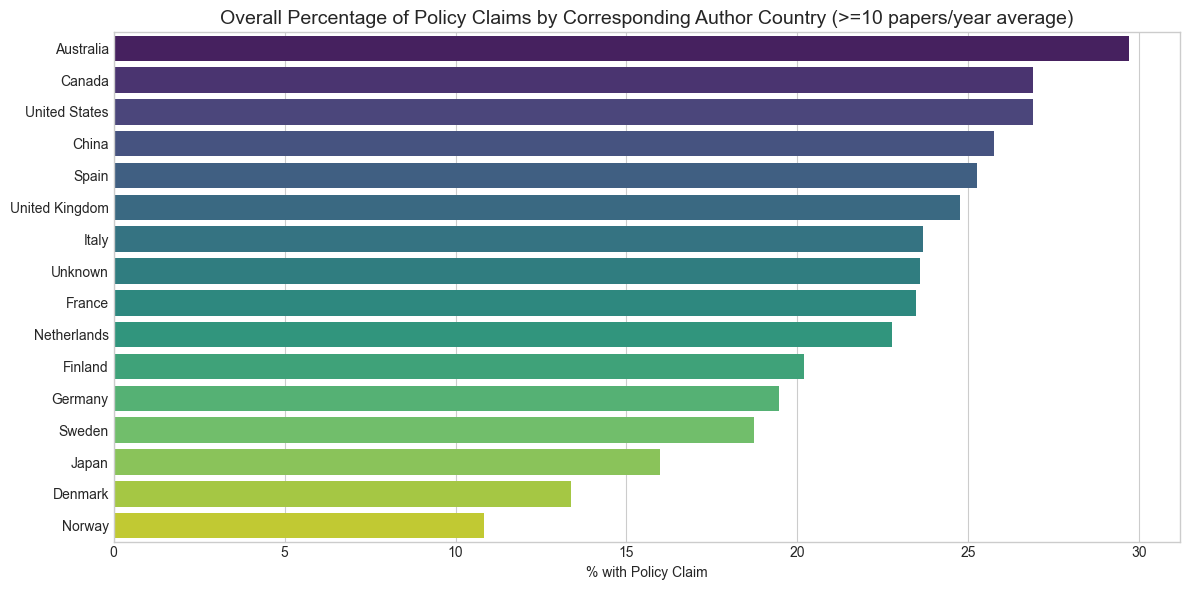

In [111]:
# Determine countries with at least 10 papers per year on average
# Compute country x year counts
counts_by_country_year = df.groupby(['corresponding_author_country', YEAR_COLUMN]).size().unstack(fill_value=0)
# Mean papers per year for each country
mean_per_year = counts_by_country_year.mean(axis=1)
# Compute UNKNOWN count and then select countries with mean >= 10, excluding 'UNKNOWN'
unknown_count = df['corresponding_author_country'].value_counts().get('UNKNOWN', 0)
eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != 'UNKNOWN']
print(f"Countries with >=10 papers per year on average (excluding 'UNKNOWN'): {len(eligible_countries)}")
print(eligible_countries)
print(f"Number of 'UNKNOWN' corresponding_author_country entries removed from the analysis: {unknown_count}")

if len(eligible_countries) == 0:
    print('No countries meet the 10 papers/year threshold; skipping country-level analyses')
else:
    # Overall percentage of policy claims for eligible countries
    overall_country_rate = (
        df[df['corresponding_author_country'].isin(eligible_countries)]
        .groupby('corresponding_author_country')['claim']
        .mean()
        .reset_index()
    )
    plot_country_data = overall_country_rate.sort_values(by='claim', ascending=False)
    plot_country_data['percent_claim'] = plot_country_data['claim'] * 100

    plt.figure(figsize=(12, max(6, 0.3*len(plot_country_data))))
    sns.barplot(
        data=plot_country_data,
        x='percent_claim',
        y='corresponding_author_country',
        palette='viridis'
    )
    plt.title('Overall Percentage of Policy Claims by Corresponding Author Country (>=10 papers/year average)', fontsize=14)
    plt.xlabel('% with Policy Claim')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "overall_percent_by_country_10peryear.png")
    plt.show()


## Export: random sample for manual checking

In [114]:
import pandas as pd

def sample_claim_abstracts(
    data: pd.DataFrame,
    n_per_journal: int = 5,
    start_year: int = 2020,
    end_year: int = 2024,
    seed: int = 123,
    require_exact: bool = False,
    journal_col: str = "journal",
    year_col: str = "publication_year",
    claim_col: str | None = None,
) -> pd.DataFrame:
    """
    Filter to [start_year, end_year] and claim==1/True, then sample up to
    n_per_journal per journal (exact if require_exact=True). Returns a new DataFrame.
    Assumes `data` is an in-memory DataFrame (no file I/O).
    """

    # Pick the claim column
    if claim_col is None:
        for cand in ("claim", "llm_policy_claim"):
            if cand in data.columns:
                claim_col = cand
                break
    if claim_col is None:
        raise ValueError("Need a 'claim' or 'llm_policy_claim' column (or pass claim_col=...).")

    # Column checks
    if journal_col not in data.columns:
        raise ValueError(f"Missing '{journal_col}' column.")
    if year_col not in data.columns:
        raise ValueError(f"Missing '{year_col}' column.")

    # Coerce year
    year = pd.to_numeric(data[year_col], errors="coerce")

    # Build a robust claim mask
    s = data[claim_col]
    if s.dtype == bool:
        claim_mask = s.fillna(False)
    else:
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().any():
            claim_mask = (s_num == 1).fillna(False)
        else:
            claim_mask = s.astype(str).str.strip().str.lower().isin({"1", "true", "yes"})

    # Filter
    sub = data.loc[year.between(start_year, end_year, inclusive="both") & claim_mask].copy()
    if sub.empty:
        raise ValueError("No rows match filters (years and claim).")

    # Enforce availability if needed
    counts = sub[journal_col].value_counts()
    if require_exact:
        few = counts[counts < n_per_journal]
        if not few.empty:
            raise ValueError(
                "Journals with fewer than "
                f"{n_per_journal}: " + ", ".join(f"{j}({c})" for j, c in few.items())
            )

    # Sample per journal, deterministically
    sampled = (
        sub.groupby(journal_col, group_keys=False)
           .apply(lambda g: g.sample(n=min(len(g), n_per_journal), random_state=seed))
           .sample(frac=1, random_state=seed)  # shuffle final result
           .reset_index(drop=True)
    )

    return sampled


def sample_claim_abstracts_overall(
    data: pd.DataFrame,
    n_total: int = 100,
    start_year: int = 2020,
    end_year: int = 2024,
    seed: int = 123,
    year_col: str = "publication_year",
    claim_col: str | None = None,
) -> pd.DataFrame:
    """
    Filter to [start_year, end_year] and claim==1/True, then sample n_total
    abstracts regardless of journal. Returns a new DataFrame.
    """

    # Pick the claim column
    if claim_col is None:
        for cand in ("claim", "llm_policy_claim"):
            if cand in data.columns:
                claim_col = cand
                break
    if claim_col is None:
        raise ValueError("Need a 'claim' or 'llm_policy_claim' column (or pass claim_col=...).")

    # Column checks
    if year_col not in data.columns:
        raise ValueError(f"Missing '{year_col}' column.")

    # Coerce year
    year = pd.to_numeric(data[year_col], errors="coerce")

    # Build a robust claim mask
    s = data[claim_col]
    if s.dtype == bool:
        claim_mask = s.fillna(False)
    else:
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().any():
            claim_mask = (s_num == 1).fillna(False)
        else:
            claim_mask = s.astype(str).str.strip().str.lower().isin({"1", "true", "yes"})

    # Filter
    sub = data.loc[year.between(start_year, end_year, inclusive="both") & claim_mask].copy()
    if sub.empty:
        raise ValueError("No rows match filters (years and claim).")

    # Sample overall (random selection across all journals)
    sampled = sub.sample(n=min(len(sub), n_total), random_state=seed).reset_index(drop=True)

    return sampled

In [115]:
import json
import numpy as np

# 1) Sample
sampled_by_journal = sample_claim_abstracts(df, n_per_journal=5, start_year=2020, end_year=2024, seed=123)
sampled_overall  = sample_claim_abstracts_overall(df, n_total=100, start_year=2020, end_year=2024, seed=123)

# 2) Choose column order (fallback to all if missing)
preferred = ["journal","publication_year","title","abstract","keywords","doi","pmid","claim","llm_policy_claim"]
cols_j = [c for c in preferred if c in sampled_by_journal.columns] or sampled_by_journal.columns.tolist()
cols_o = [c for c in preferred if c in sampled_overall.columns] or sampled_overall.columns.tolist()

def prep_for_csv(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return ", ".join(map(str, x))
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    return x

# 3) Clean + export
out_j = sampled_by_journal[cols_j].copy()
out_o = sampled_overall[cols_o].copy()
out_j.columns = [str(c) for c in out_j.columns]
out_o.columns = [str(c) for c in out_o.columns]
for c in out_j.columns: out_j[c] = out_j[c].apply(prep_for_csv)
for c in out_o.columns: out_o[c] = out_o[c].apply(prep_for_csv)

for df_out, fn in [
    (out_j, "../table/supp_sampled_policy_claims_by_journal_2020_2024.csv"),
    (out_o, "../table/supp_sampled_policy_claims_overall_2020_2024.csv"),
]:
    with open(fn, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow([str(c) for c in df_out.columns])
        w.writerows(df_out.astype(str).to_numpy())

## Gold standard check: manual vs LLM

## 400-paper stratified validation sample

### Step 1: Generate stratified sample for manual review

Draws a year-stratified sample of 400 abstracts. Exports a blinded file (no year or LLM label) for the human reviewer and an internal file (with LLM labels) for later comparison. Requires `df` to be loaded — run **Cell 4** (Setup and Configuration) first.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr

SAMPLE_N = 400
SAMPLE_SEED = 20260327
OUT_DIR = Path("../table")
OUT_DIR.mkdir(parents=True, exist_ok=True)

sample_df = df.copy()
sample_df = sample_df.dropna(subset=["llm_policy_claim", "publication_year"]).copy()
sample_df["publication_year"] = pd.to_numeric(sample_df["publication_year"], errors="coerce")
sample_df = sample_df.dropna(subset=["publication_year"]).copy()
sample_df["publication_year"] = sample_df["publication_year"].astype(int)
sample_df["claim"] = sample_df["llm_policy_claim"].astype(bool)

years = sorted(sample_df["publication_year"].unique())
n_years = len(years)
base_n = SAMPLE_N // n_years
remainder = SAMPLE_N % n_years

rng = np.random.default_rng(SAMPLE_SEED)
extra_years = set(rng.choice(years, size=remainder, replace=False)) if remainder else set()
target_n_by_year = {y: base_n + (1 if y in extra_years else 0) for y in years}

too_small = {
    y: int((sample_df["publication_year"] == y).sum())
    for y in years
    if (sample_df["publication_year"] == y).sum() < target_n_by_year[y]
}
if too_small:
    raise ValueError(f"Not enough records in some years for the requested stratified sample: {too_small}")

stratified_400 = (
    sample_df.groupby("publication_year", group_keys=False)
    .apply(lambda g: g.sample(n=target_n_by_year[int(g.name)], random_state=SAMPLE_SEED))
    .sample(frac=1, random_state=SAMPLE_SEED)
    .reset_index(drop=True)
)

# Add blinded review id
stratified_400.insert(0, "review_id", [f"S400-{i:03d}" for i in range(1, len(stratified_400) + 1)])

# Blinded review file: hide year and LLM claim
blinded_cols = [c for c in [
    "review_id", "scopus_id", "doi", "title", "journal", "keywords", "abstract"
] if c in stratified_400.columns]

blinded_path = OUT_DIR / "supp_stratified_sample_400_blinded.xlsx"
stratified_400[blinded_cols].to_excel(blinded_path, index=False)

# Internal file: keep year and LLM claim for checking
internal_cols = [c for c in [
    "review_id", "scopus_id", "doi", "title", "journal",
    "publication_year", "keywords", "abstract", "llm_policy_claim"
] if c in stratified_400.columns]

internal_path = OUT_DIR / "supp_stratified_sample_400_internal.xlsx"
stratified_400[internal_cols].to_excel(internal_path, index=False)

full_yearly = (
    sample_df.groupby("publication_year")
    .agg(n_full=("claim", "size"), pct_full=("claim", lambda x: 100 * x.mean()))
    .reset_index()
)

sample_yearly = (
    stratified_400.groupby("publication_year")
    .agg(n_sample=("claim", "size"), pct_sample=("claim", lambda x: 100 * x.mean()))
    .reset_index()
)

trend_check = full_yearly.merge(sample_yearly, on="publication_year", how="left")

full_rho, full_p = spearmanr(trend_check["publication_year"], trend_check["pct_full"])
sample_rho, sample_p = spearmanr(trend_check["publication_year"], trend_check["pct_sample"])

print(f"Saved blinded review file to: {blinded_path.as_posix()}")
print(f"Saved internal check file to: {internal_path.as_posix()}")
print(f"Years covered: {min(years)}-{max(years)} ({n_years} years)")
print(f"Target per year: {base_n} each, with +1 in {remainder} randomly selected years")

print("\nSample size by year:")
print(sample_yearly[["publication_year", "n_sample"]].to_string(index=False))

print("\nTrend check (Spearman correlation of year with claim rate):")
print(f"Full analytic sample: rho={full_rho:.3f}, p={full_p:.4g}")
print(f"Stratified 400 sample: rho={sample_rho:.3f}, p={sample_p:.4g}")

print("\nInterpretation:")
if pd.notna(sample_rho) and sample_rho > 0:
    print("The stratified sample retains an increasing year-on-year claim-rate trend.")
else:
    print("The sampled trend is not clearly increasing; re-sampling may be needed.")

trend_check


### Step 2: Check sample representativeness by time period

Compares policy claim rates across four time periods between the full analytic sample and the stratified 400. Confirms the sample preserves the overall temporal trend.

In [8]:
import pandas as pd

periods = {
    "1990-1999": (1990, 2000),
    "2000-2009": (2000, 2010),
    "2010-2019": (2010, 2020),
    "2020-2024": (2020, 2025),
}

def summarize_claim_rate_by_period(data, label):
    tmp = data.copy()
    tmp = tmp.dropna(subset=["llm_policy_claim", "publication_year"]).copy()
    tmp["publication_year"] = pd.to_numeric(tmp["publication_year"], errors="coerce")
    tmp = tmp.dropna(subset=["publication_year"]).copy()
    tmp["publication_year"] = tmp["publication_year"].astype(int)
    tmp["claim"] = tmp["llm_policy_claim"].astype(bool)

    rows = []
    for period, (start, end) in periods.items():
        sub = tmp[(tmp["publication_year"] >= start) & (tmp["publication_year"] < end)].copy()
        n_articles = len(sub)
        n_claims = int(sub["claim"].sum())
        claim_rate_pct = 100 * n_claims / n_articles if n_articles else float("nan")
        rows.append({
            "sample": label,
            "period": period,
            "n_articles": n_articles,
            "n_claims": n_claims,
            "claim_rate_pct": round(claim_rate_pct, 1),
        })
    return pd.DataFrame(rows)

full_period_summary = summarize_claim_rate_by_period(df, "Full analytic sample")
selected_period_summary = summarize_claim_rate_by_period(stratified_400, "Selected sample")

period_summary_compare = pd.concat(
    [full_period_summary, selected_period_summary],
    ignore_index=True
)

display(period_summary_compare)

for sample_name, subdf in period_summary_compare.groupby("sample"):
    print(f"\n{sample_name}")
    for _, r in subdf.iterrows():
        print(f"{r['period']}: {r['claim_rate_pct']:.1f}% ({r['n_claims']}/{r['n_articles']})")


,sample,period,n_articles,n_claims,claim_rate_pct
0,Full analytic sample,1990-1999,10436,1841,17.6
1,Full analytic sample,2000-2009,12529,2857,22.8
2,Full analytic sample,2010-2019,15464,4394,28.4
3,Full analytic sample,2020-2024,7378,2643,35.8
4,Selected sample,1990-1999,114,15,13.2
5,Selected sample,2000-2009,115,26,22.6
6,Selected sample,2010-2019,114,31,27.2
7,Selected sample,2020-2024,57,25,43.9



Full analytic sample
1990-1999: 17.6% (1841/10436)
2000-2009: 22.8% (2857/12529)
2010-2019: 28.4% (4394/15464)
2020-2024: 35.8% (2643/7378)

Selected sample
1990-1999: 13.2% (15/114)
2000-2009: 22.6% (26/115)
2010-2019: 27.2% (31/114)
2020-2024: 43.9% (25/57)


### Step 3: Compute concordance between manual and LLM labels

After the reviewer has filled in the blinded file with their own `manual_policy_claim` labels, this cell loads both files, merges on `review_id`, and reports percent agreement, Cohen's kappa, a confusion matrix, and sensitivity/specificity.

In [ ]:
# Load the completed blinded review file (reviewer must have added a 'manual_policy_claim' column)
# and compare against the LLM labels from the internal file.
from pathlib import Path
import pandas as pd
import numpy as np

REVIEW_FILE  = Path("../table/supp_stratified_sample_400_blinded.xlsx")   # completed by reviewer
INTERNAL_FILE = Path("../table/supp_stratified_sample_400_internal.xlsx") # LLM labels
MANUAL_COL   = "manual_policy_claim"   # column the reviewer should add to the blinded file

if not REVIEW_FILE.exists():
    print(f"Review file not found: {REVIEW_FILE.as_posix()}")
    print("Complete the manual review and re-run this cell.")
elif not INTERNAL_FILE.exists():
    print(f"Internal file not found: {INTERNAL_FILE.as_posix()}")
    print("Run Step 1 first to generate the sample files.")
else:
    reviewed = pd.read_excel(REVIEW_FILE)
    if MANUAL_COL not in reviewed.columns:
        print(f"Column '{MANUAL_COL}' not found in {REVIEW_FILE.name}.")
        print(f"Please add a column named '{MANUAL_COL}' (True/False) to the blinded review file.")
    else:
        internal = pd.read_excel(INTERNAL_FILE)
        merged = (
            reviewed[["review_id", MANUAL_COL]]
            .merge(internal[["review_id", "llm_policy_claim"]], on="review_id", how="inner")
        )

        merged["manual"] = merged[MANUAL_COL].astype(bool)
        merged["llm"]    = merged["llm_policy_claim"].astype(bool)

        n     = len(merged)
        tp    = int(( merged["manual"] &  merged["llm"]).sum())
        tn    = int((~merged["manual"] & ~merged["llm"]).sum())
        fp    = int((~merged["manual"] &  merged["llm"]).sum())
        fn    = int(( merged["manual"] & ~merged["llm"]).sum())
        agree = tp + tn

        p_o   = agree / n
        p_e   = ((tp + fn) / n) * ((tp + fp) / n) + ((fp + tn) / n) * ((fn + tn) / n)
        kappa = (p_o - p_e) / (1 - p_e) if p_e < 1 else float("nan")

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        ppv = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        npv = tn / (tn + fn) if (tn + fn) > 0 else float("nan")

        conf = pd.DataFrame(
            [[tp, fn], [fp, tn]],
            index=["Manual: True", "Manual: False"],
            columns=["LLM: True", "LLM: False"],
        )

        print(f"N compared: {n}")
        print(f"Percent agreement: {100 * p_o:.1f}%")
        print(f"Cohen's kappa:     {kappa:.3f}")
        print()
        print("Confusion matrix (rows = manual label, cols = LLM label):")
        display(conf)
        print()
        print(f"Sensitivity (LLM detects manual True):  {sensitivity:.3f}")
        print(f"Specificity (LLM detects manual False): {specificity:.3f}")
        print(f"PPV: {ppv:.3f}  |  NPV: {npv:.3f}")


## Comparison: study designs (manual vs LLM)

### Coverage check: proportion of abstracts with study design assigned

Reports how many abstracts received a non-null, non-'Other/None' study design label from the LLM classification pipeline.

In [126]:
tmp = df.copy()

n_total = len(tmp)
n_assigned = tmp["design_combined"].notna() & tmp["design_combined"].ne("Other/None")
n_assigned = int(n_assigned.sum())
pct_assigned = 100 * n_assigned / n_total if n_total else float("nan")

print(f"Study design assigned: {n_assigned:,} abstracts")
print(f"Total abstracts: {n_total:,}")
print(f"Percent assigned: {pct_assigned:.1f}%")

Study design assigned: 8,715 abstracts
Total abstracts: 45,807
Percent assigned: 19.0%


## Comparison: research topics (manual vs LLM)

### Coverage check: proportion of abstracts with research topics/keywords assigned

Reports how many abstracts have at least one keyword or topic label.

In [13]:
import pandas as pd

tmp = df.copy()

def has_keywords(x):
    if pd.isna(x):
        return False
    if isinstance(x, list):
        return len(x) > 0
    if isinstance(x, str):
        s = x.strip()
        return s not in {"", "[]", "[ ]"}
    return False

keyword_mask = tmp["keywords"].apply(has_keywords)

n_total = len(tmp)
n_with_keywords = int(keyword_mask.sum())
pct_with_keywords = 100 * n_with_keywords / n_total if n_total else float("nan")

print(
    f"{n_with_keywords:,} abstracts had keywords "
    f"({pct_with_keywords:.1f}% of all {n_total:,})."
)

23,982 abstracts had keywords (52.4% of all 45,807).


## study design sensitivity analysis

In [ ]:
"""
Manual review analysis: compare policy claim rates by study design using the
completed design-review workbook (400 reviewed records).

Compares claim rates across:
    - manual_check1                    (manual design labels entered by reviewer)
    - design_combined                  (main automated classifier)
    - design_combined_unambiguous      (combined, multi-match rows blanked)

The reviewer labels in manual_check1 are lower-case, so labels are normalised
before comparison.
"""

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
INPUT_XLSX = Path("../table/manual_review_by_design_50_each_EC.xlsx")
OUTPUT_PNG = Path("../data/analysis/manual_review_claim_rate_by_design_sensitivity.png")

CLAIM_COL = "llm_policy_claim"
MANUAL_COL = "manual_check1"
CLASSIFIERS = [
    MANUAL_COL,
    "design_combined",
    "design_combined_unambiguous",
]

CLASSIFIER_LABELS = {
    MANUAL_COL: "Manual review",
    "design_combined": "algorithm (title/keywords)",
    "design_combined_unambiguous": "algorithm (title/keywords, excl. multiple study designs)",
}

DESIGN_ORDER = [
    "Experimental",
    "Quasi-experimental",
    "Cohort",
    "Cross-sectional",
    "Ecological / Time-series",
    "Case-control",
    "Qualitative",
]

MIN_N_TO_PLOT = 1


def normalize_design_label_auto(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    key = re.sub(r"\s+", " ", text).strip().lower()
    mapping = {
        "experimental": "Experimental",
        "quasi-experimental": "Quasi-experimental",
        "quasi experimental": "Quasi-experimental",
        "cohort": "Cohort",
        "cross-sectional": "Cross-sectional",
        "cross sectional": "Cross-sectional",
        "ecological": "Ecological / Time-series",
        "ecological study": "Ecological / Time-series",
        "ecological / time-series": "Ecological / Time-series",
        "ecological/time-series": "Ecological / Time-series",
        "ecological / time series": "Ecological / Time-series",
        "ecological time-series": "Ecological / Time-series",
        "ecological time series": "Ecological / Time-series",
        "time-series": "Ecological / Time-series",
        "time series": "Ecological / Time-series",
        "times series": "Ecological / Time-series",
        "case-control": "Case-control",
        "case control": "Case-control",
        "qualitative": "Qualitative",
        "other/none": "Other/None",
        "other / none": "Other/None",
        "other none": "Other/None",
        "other": "Other/None",
        "none": "Other/None",
    }
    return mapping.get(key, text)


def normalize_design_label_manual(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    key = re.sub(r"\s+", " ", text).strip().lower()
    mapping = {
        "experimental": "Experimental",
        "quasi-experimental": "Quasi-experimental",
        "quasi experimental": "Quasi-experimental",
        "cohort": "Cohort",
        "cross-sectional": "Cross-sectional",
        "cross sectional": "Cross-sectional",
        "ecological": "Ecological / Time-series",
        "ecological study": "Ecological / Time-series",
        "ecological / time-series": "Ecological / Time-series",
        "ecological/time-series": "Ecological / Time-series",
        "ecological / time series": "Ecological / Time-series",
        "ecological time-series": "Ecological / Time-series",
        "ecological time series": "Ecological / Time-series",
        "time-series": "Ecological / Time-series",
        "time series": "Ecological / Time-series",
        "times series": "Ecological / Time-series",
        "case-control": "Case-control",
        "case control": "Case-control",
        "qualitative": "Qualitative",
        "other/none": "Other/None",
        "other / none": "Other/None",
        "other none": "Other/None",
        "other": "Other/None",
        "none": "Other/None",
    }
    return mapping.get(key, text)


# -------------------- LOAD --------------------
df = pd.read_excel(INPUT_XLSX)

required_cols = {CLAIM_COL, MANUAL_COL, "design_combined", "design_combined_unambiguous"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns in {INPUT_XLSX.name}: {sorted(missing)}")

df[CLAIM_COL] = pd.to_numeric(df[CLAIM_COL], errors="coerce")
df = df[df[CLAIM_COL].notna()].copy()
df[CLAIM_COL] = df[CLAIM_COL].astype(bool)

# Keep the completed manual-review records only.
df[MANUAL_COL] = df[MANUAL_COL].apply(normalize_design_label_manual)
df = df[df[MANUAL_COL].notna()].copy()

for col in ["design_combined", "design_combined_unambiguous"]:
    df[col] = df[col].apply(normalize_design_label_auto)

print(f"Loaded {len(df)} reviewed records from {INPUT_XLSX.name}.")

# -------------------- CONCORDANCE --------------------
def cohen_kappa_from_labels(y_true, y_pred):
    paired = pd.DataFrame({"true": y_true, "pred": y_pred}).dropna()
    if paired.empty:
        return np.nan, 0, np.nan

    labels = sorted(set(paired["true"]).union(set(paired["pred"])))
    confusion = pd.crosstab(
        pd.Categorical(paired["true"], categories=labels),
        pd.Categorical(paired["pred"], categories=labels),
        dropna=False,
    ).to_numpy()
    n = confusion.sum()
    observed = np.trace(confusion) / n
    expected = (confusion.sum(axis=1) * confusion.sum(axis=0)).sum() / (n * n)
    kappa = (observed - expected) / (1 - expected) if expected != 1 else np.nan
    return kappa, int(n), observed * 100


kappa_rows = []
for clf in ["design_combined", "design_combined_unambiguous"]:
    kappa, n_pairs, pct_agreement = cohen_kappa_from_labels(df[MANUAL_COL], df[clf])
    kappa_rows.append({
        "comparison": f"Manual review vs {CLASSIFIER_LABELS[clf]}",
        "n": n_pairs,
        "percent_agreement": pct_agreement,
        "cohens_kappa": kappa,
    })

kappa_summary = pd.DataFrame(kappa_rows)
print("\n=== Study-design concordance with manual review ===")
print(kappa_summary.to_string(index=False, formatters={
    "percent_agreement": lambda x: f"{x:.1f}",
    "cohens_kappa": lambda x: f"{x:.3f}",
}))

# -------------------- BUILD LONG TABLE --------------------
rows = []
for clf in CLASSIFIERS:
    for design in DESIGN_ORDER:
        mask = df[clf] == design
        n = int(mask.sum())
        claims = df.loc[mask, CLAIM_COL]
        pct = (claims.mean() * 100) if n > 0 else np.nan
        rows.append({
            "classifier": clf,
            "classifier_label": CLASSIFIER_LABELS[clf],
            "design": design,
            "n": n,
            "pct_claim": pct,
        })

summary = pd.DataFrame(rows)

# -------------------- PRINT UNDERLYING NUMBERS --------------------
print("\n=== Policy claim rate (%) by design and classifier ===")
pct_wide = summary.pivot(index="design", columns="classifier_label", values="pct_claim")
pct_wide = pct_wide.reindex(DESIGN_ORDER)
pct_wide = pct_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(pct_wide.round(1).to_string())

print("\n=== N per cell ===")
n_wide = summary.pivot(index="design", columns="classifier_label", values="n")
n_wide = n_wide.reindex(DESIGN_ORDER)
n_wide = n_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(n_wide.astype("Int64").to_string())

# -------------------- PLOT --------------------
x = np.arange(len(DESIGN_ORDER))
bar_width = 0.8 / len(CLASSIFIERS)
colours = ["#0173B2", "#DE8F05", "#029E73"]

fig, ax = plt.subplots(figsize=(12, 7))

for i, clf in enumerate(CLASSIFIERS):
    sub = summary[summary["classifier"] == clf].set_index("design").reindex(DESIGN_ORDER)
    heights = sub["pct_claim"].to_numpy()
    ns = sub["n"].to_numpy()
    heights = np.where(ns >= MIN_N_TO_PLOT, heights, np.nan)

    offset = (i - (len(CLASSIFIERS) - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset,
        heights,
        width=bar_width,
        color=colours[i],
        label=CLASSIFIER_LABELS[clf],
        edgecolor="white",
        linewidth=0.5,
    )

    for j, (bar, n) in enumerate(zip(bars, ns)):
        if np.isnan(heights[j]):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set_xticks(x)
ax.set_xticklabels(DESIGN_ORDER, rotation=25, ha="right")
ax.set_ylabel("% with policy claim")
ax.set_title("Manual-review sample: policy claim rate by study design classifier", fontsize=13)
ax.set_ylim(0, max(summary["pct_claim"].max() * 1.18, 55))
ax.legend(title="Classifier", loc="upper left", frameon=True, fontsize=9, title_fontsize=9)
ax.text(
    0.0,
    -0.20,
    "Numbers above bars show N in each cell. Ecological and time-series manual labels were combined before comparison.",
    transform=ax.transAxes,
    fontsize=8,
    color="gray",
    style="italic",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

fig.tight_layout()
OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
print(f"\nSaved plot: {OUTPUT_PNG}")
